In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from matplotlib.patches import Patch, Rectangle
from matplotlib.colors import ListedColormap
import networkx as nx
from scipy.stats import gaussian_kde
import joypy
from sklearn.metrics import auc
import os, re, glob
from matplotlib.image import imread
from PIL import Image, ImageOps
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from umap.umap_ import UMAP
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings


# 读取Excel文件
excel_path = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比（带模型）.xlsx"
df = pd.read_excel(excel_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 查看数据结构
print("数据形状:", df.shape)
print("\n列名:")
print(df.columns.tolist())


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


matplotlib 识别的字体名: Songti SC
数据形状: (9, 10)

列名:
['任务组', '阴性组vs其他', '感染性v非感染组', '细菌性vs其他感染性', '病毒性vs其他感染性', '结核性vs其他感染性', '真菌性vs其他感染性', '肿瘤性vs其他', '自身免疫性vs其他', '病毒性脑膜炎vs病毒性脑炎']


In [ ]:
# 中英文转换

feature_comb_trans = {
    "血液40项+脑脊液18项": "Blood 40 + CSF 18",
    "血液203项+脑脊液18项": "Blood 203 + CSF 18",
    "血液40项": "Blood 40",
    "血液203项": "Blood 203",
    "脑脊液18项": "CSF 18",
    "脑脊液8项": "CSF 8",
    "血液40项+脑脊液8项": "Blood 40 + CSF 8",
    "血液203+脑脊液8": "Blood 203 + CSF 8",
    "精选特征集": "Selected Features Set"
}
task_trans1 = {
    "阴性组vs其他": "NG vs Others",
    "感染性v非感染组": "Infectious Meningitis vs Non-Infectious ",
    "细菌性vs其他感染性": "BM vs Other Infectious Meningitis",
    "病毒性vs其他感染性": "VM vs Other Infectious Meningitis",
    "结核性vs其他感染性": "TBM vs Other Infectious Meningitis",
    "真菌性vs其他感染性": "FM vs Other Infectious Meningitis",
    "肿瘤性vs其他": "LM vs Others",
    "自身免疫性vs其他": "AM vs Others",
    "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
}
task_trans2 = {
    '阴性组vs其他': 'NG vs Others',
    '感染性脑膜炎vs非感染性脑膜炎': 'Infectious Meningitis vs Non-Infectious ',
    '细菌性脑膜炎vs其他感染性脑膜炎': 'BM vs Other Infectious Meningitis',
    '病毒性脑膜炎vs其他感染性脑膜炎': 'VM vs Other Infectious Meningitis',
    '结核性脑膜炎vs其他感染性脑膜炎': 'TBM vs Other Infectious Meningitis',
    '真菌性脑膜炎vs其他感染性脑膜炎': 'FM vs Other Infectious Meningitis',
    '肿瘤性脑膜炎vs其他': 'LM vs Others',
    '自身免疫性脑膜炎vs其他': 'AM vs Others',
    '病毒性脑膜炎vs病毒性脑炎': 'VM vs VE'
}
task_trans3 = {
    '阴性组vs其他': 'NG vs Others',
    '感染性v非感染组': 'IM vs Non-IM ',
    '细菌性vs其他感染性': 'BM vs OIM',
    '病毒性vs其他感染性': 'VM vs OIM',
    '结核性vs其他感染性': 'TBM vs OIM',
    '真菌性vs其他感染性': 'FM vs OIM',
    '肿瘤性vs其他': 'LM vs Others',
    '自身免疫性vs其他': 'AM vs Others',
    '病毒性脑膜炎vs病毒性脑炎': 'VM vs VE'
}

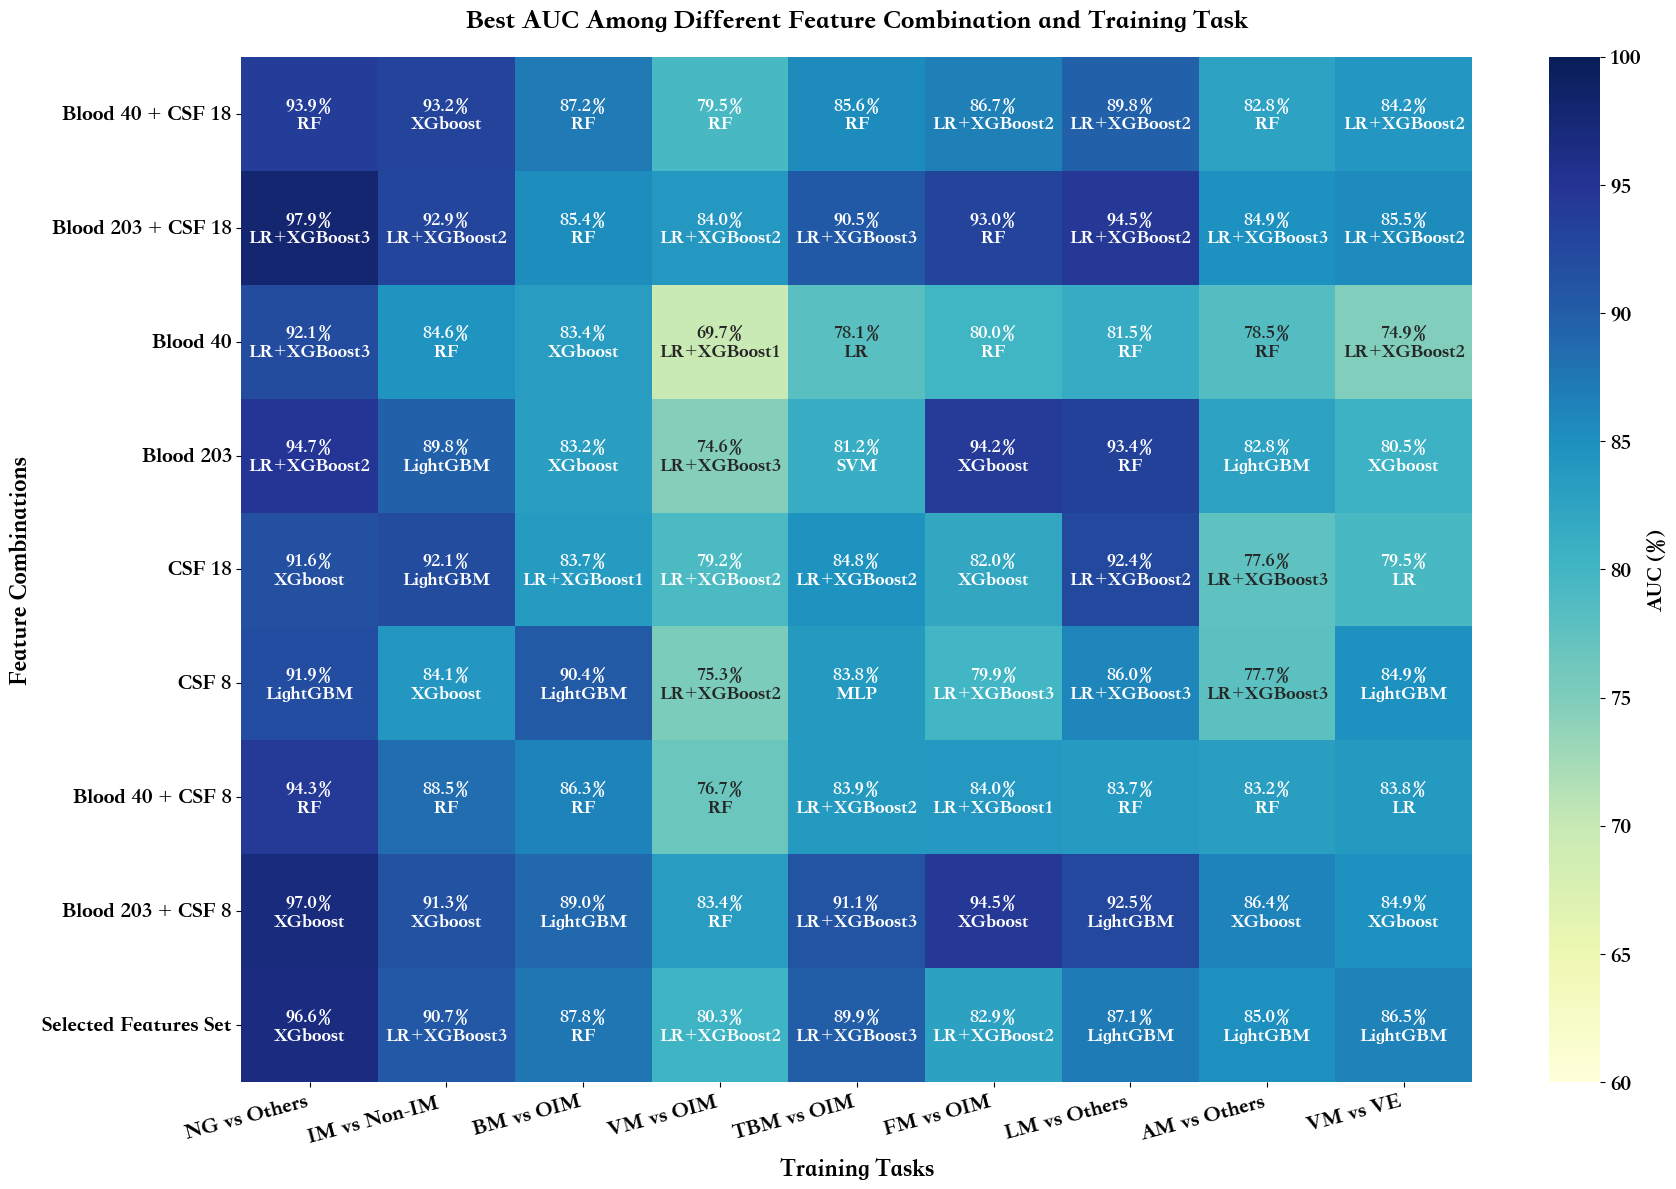

改进的热力图已保存到 heatmap_with_accuracy_and_models.png


In [ ]:

# -------------------------------------热力图 - 加上模型信息✅----------------------------------------------

# 读取Excel文件
excel_path = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/全部模型最优结果对比（带模型）.xlsx"
df = pd.read_excel(excel_path)
df_copy = df.copy()


df = df.rename(columns=task_trans3)
df["任务组"] = [y for x, y in feature_comb_trans.items()]
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 提取数值和模型信息
def extract_accuracy_model(cell_value):
    """提取准确率和模型信息"""
    if pd.isna(cell_value):
        return np.nan, ""
    
    # 使用正则表达式提取百分数和模型
    match = re.match(r'(\d+\.?\d*)%?\((.*?)\)', str(cell_value))
    if match:
        accuracy = float(match.group(1))
        model = match.group(2)
        return accuracy, model
    else:
        # 如果没有括号，尝试直接提取数字
        try:
            accuracy = float(str(cell_value).replace('%', ''))
            return accuracy, ""
        except:
            return np.nan, ""

# 创建数值矩阵和模型矩阵
numeric_data = np.zeros((len(df), len(df.columns) - 1))
model_data = np.empty((len(df), len(df.columns) - 1), dtype=object)

for i in range(len(df)):
    for j in range(1, len(df.columns)):  # 跳过第一列（任务组）
        accuracy, model = extract_accuracy_model(df.iloc[i, j])
        numeric_data[i, j-1] = accuracy
        model_data[i, j-1] = model

# 创建组合的注释文本（准确率+模型）
annot_text = np.empty_like(model_data)
for i in range(len(df)):
    for j in range(len(df.columns) - 1):
        if not pd.isna(numeric_data[i, j]):
            annot_text[i, j] = f"{numeric_data[i, j]:.1f}%\n{model_data[i, j]}"
        else:
            annot_text[i, j] = ""

# 创建热力图
fig, ax = plt.subplots(figsize=(18, 12))

# 使用seaborn创建热力图
ax = sns.heatmap(numeric_data, 
            annot=annot_text,  # 使用组合文本作为注释
            fmt='',  # 不设置格式，因为我们自定义格式
            cmap='YlGnBu', 
            vmin=60, vmax=100,
            cbar_kws={'label': 'AUC (%)'},
            ax=ax,
            annot_kws={'size': 14, 'va': 'center'})  # 调整注释文本大小和对齐方式
cbar = ax.collections[0].colorbar  # 取得 colorbar
cbar.ax.tick_params(labelsize=16)  # 刻度字号
cbar.ax.set_ylabel('AUC (%)', fontsize=16)  # 轴标签字号
# 设置轴标签
ax.set_xticks(np.arange(len(df.columns) - 1) + 0.5)
ax.set_xticklabels(df.columns[1:], rotation=15, ha='right', fontsize=16)
ax.set_yticks(np.arange(len(df)) + 0.5)
ax.set_yticklabels(df['任务组'], rotation=0, fontsize=16)

# 添加标题
ax.set_title('Best AUC Among Different Feature Combination and Training Task', fontsize=20, pad=20)
ax.set_xlabel("Training Tasks", labelpad=8, fontsize=18, fontweight="bold", loc="center")
ax.set_ylabel("Feature Combinations", labelpad=8, fontsize=18, fontweight="bold", loc="center")

# 调整布局，为标签留出更多空间
plt.tight_layout()
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/AUC热力图.png')
# 显示图形
plt.show()

# 保存图形
# plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/heatmap_with_accuracy_and_models.png', 
#             dpi=300, bbox_inches='tight')

print("改进的热力图已保存到 heatmap_with_accuracy_and_models.png")

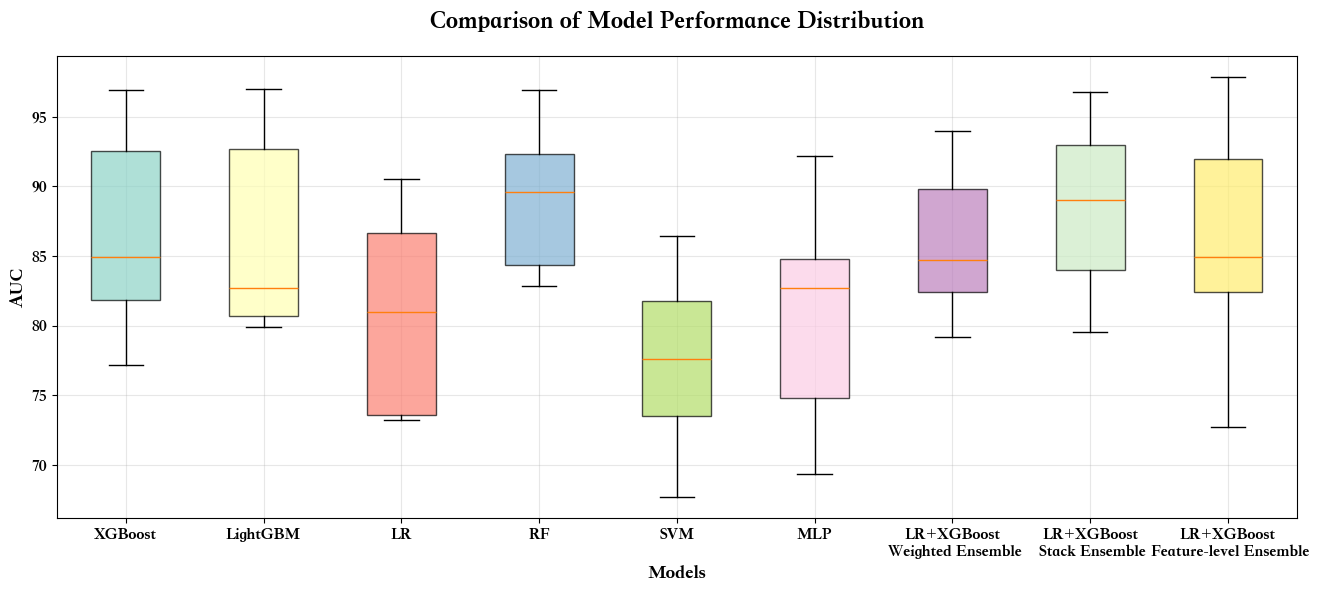

In [ ]:
# ---------------------------------------------------箱型图-----------------------------------------------------------
# 模拟10个模型的性能数据
models = ['XGBoost模型结果', 'LightGBM模型结果', 'LR模型结果', 'RF模型结果', 'SVM模型结果', 'MLP模型结果', 
          'LR+XGBoost1模型结果', 'LR+XGBoost2模型结果', 'LR+XGBoost3模型结果']

# 生成模拟性能数据（AUC值，范围0.5-1.0）
np.random.seed(42)
performance_data = []

df3 = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)


for model in models:
    base_auc = list(df3[model]['血液203项+脑脊液18项'])
    base_auc = [round(x*100,2) for x in base_auc]
    performance_data.append(base_auc)
# for model in models:
#     form = df3[model]
#     columns = list(form.columns)
#     # base_auc = list(form['血液37项+脑脊液18项'])
#     all_auc = []
#     for col in columns[1:]:
#         auc = list(form[col])
#         # base_auc = [max(i,j) for i,j in zip(base_auc, auc)]
#         auc = [round(x*100,2) for x in auc]
#         for i in auc:
#             if i > 53:
#                 continue 
#             else:
#                 auc.remove(i)
#         # auc = [x if x > 50 else 50 for x in auc]
#         all_auc = all_auc + auc
#     performance_data.append(all_auc)
# print(performance_data[5])
# new_keys = {'XGBoost模型结果': 'XGBoost', 'LightGBM模型结果': 'LightGBM', 'LR模型结果': 'LR', 'RF模型结果':'RF', 'SVM模型结果': 'SVM', 'HMM模型结果': 'HMM', 'MLP模型结果': 'MLP', 
#           'LR+XGBoost1模型结果': 'LR+XGBoost权重融合', 'LR+XGBoost2模型结果': 'LR+XGBoost堆叠融合', 'LR+XGBoost3模型结果': 'LR+XGBoost特征层融合'}

# performance_data = {new_keys.get(k, k): v for k, v in performance_data.items()}
label = ['XGBoost', 'LightGBM', 'LR', 'RF', 'SVM', 'MLP', 'LR+XGBoost Weighted Ensemble', 'LR+XGBoost Stack Ensemble', 'LR+XGBoost Feature-level Ensemble']

plt.figure(figsize=(16, 6))

box_plot = plt.boxplot(performance_data, tick_labels=[m.replace('XGBoost','XGBoost\n') for m in label], 
                      patch_artist=True)

colors_box = plt.cm.Set3(np.linspace(0, 1, len(models)))
for patch, color in zip(box_plot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Models', fontsize=14, fontweight='bold')
plt.ylabel('AUC', fontsize=14, fontweight='bold')
plt.title('Comparison of Model Performance Distribution', fontsize=18, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/boxplot.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)
plt.show()

['NG vs Others', 'Infectious Meningitis vs Non-Infectious ', 'BM vs Other Infectious Meningitis', 'VM vs Other Infectious Meningitis', 'TBM vs Other Infectious Meningitis', 'FM vs Other Infectious Meningitis', 'LM vs Others', 'AM vs Others', 'VM vs VE']


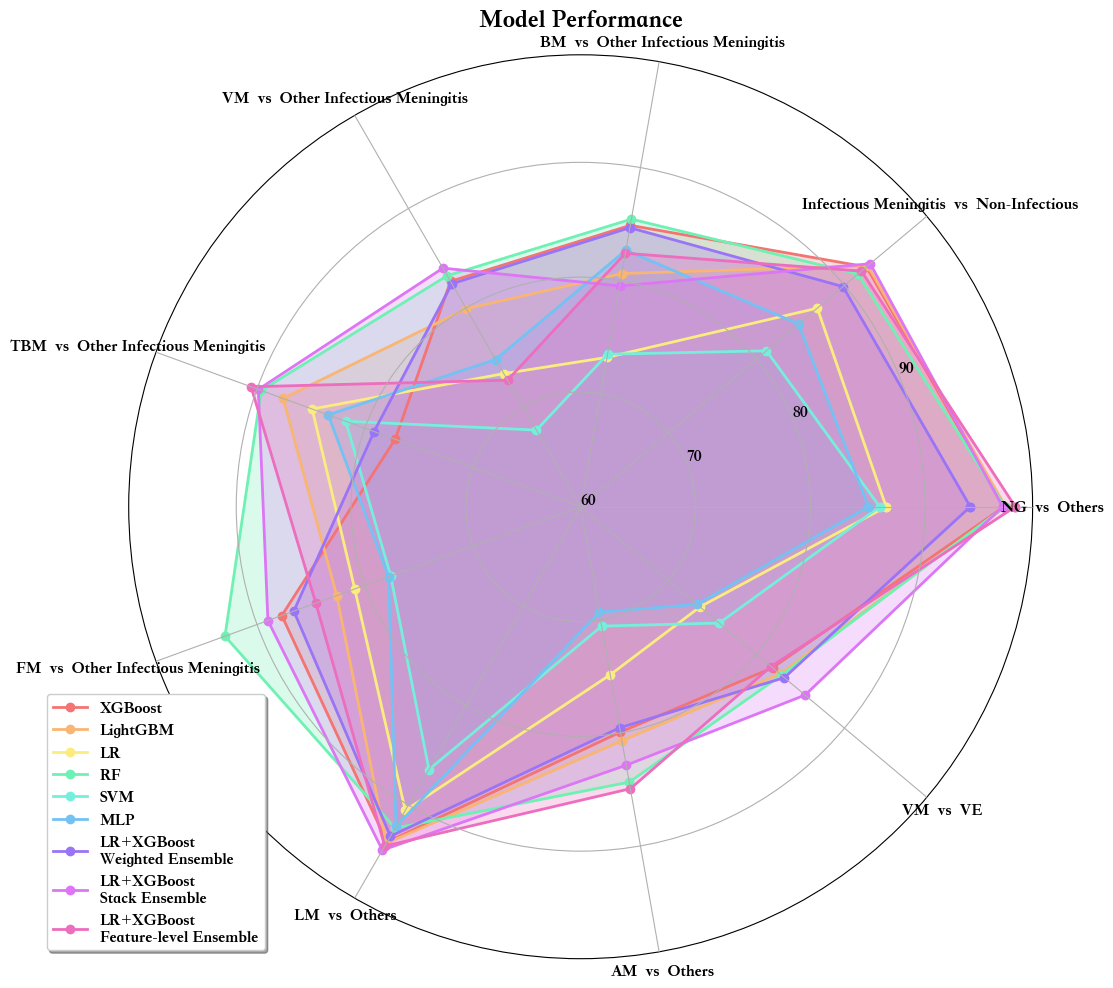

模型性能雷达图已生成


In [ ]:
# ---------------------------------------------------------雷达图-----------------------------------------------------------------
# 模拟9个任务的模型性能数据（AUC值）
tasks = [
    '阴性vs其他', '感染vs非感染', '细菌vs其他感染', 
    '病毒vs其他感染', '结核vs其他感染', '真菌vs其他感染',
    '肿瘤vs其他', '自身免疫vs其他', '病毒性脑膜炎vs脑炎'
]
tasks = [item for i, item in task_trans1.items()]
print(tasks)
# 模拟10个模型的性能数据
models = ['XGBoost模型结果', 'LightGBM模型结果', 'LR模型结果', 'RF模型结果', 'SVM模型结果', 'MLP模型结果', 
          'LR+XGBoost1模型结果', 'LR+XGBoost2模型结果', 'LR+XGBoost3模型结果']
models1 = ['XGBoost', 'LightGBM', 'LR', 'RF', 'SVM', 'MLP','LR+XGBoost Weighted Ensemble', 'LR+XGBoost Stack Ensemble', 'LR+XGBoost Feature-level Ensemble']
# 生成模拟性能数据（AUC值，范围0.5-1.0）
np.random.seed(42)
performance_data = {}

df3 = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)

for model in models:
    base_auc = list(df3[model]['血液203项+脑脊液18项'])
    base_auc = [round(x*100,2) for x in base_auc]
    performance_data[model] = base_auc

# for model in models:
#     form = df3[model]
#     columns = list(form.columns)
#     base_auc = list(form['血液37项+脑脊液18项'])
#     for col in columns[1:]:
#         auc = list(form[col])
#         base_auc = [max(i,j) for i,j in zip(base_auc, auc)]
#     base_auc = [round(x*100,2) for x in base_auc]
#     performance_data[model] = base_auc

new_keys = {'XGBoost模型结果': 'XGBoost', 'LightGBM模型结果': 'LightGBM', 'LR模型结果': 'LR', 'RF模型结果':'RF', 'SVM模型结果': 'SVM', 'MLP模型结果': 'MLP', 
          'LR+XGBoost1模型结果': 'LR+XGBoost\nWeighted Ensemble', 'LR+XGBoost2模型结果': 'LR+XGBoost\nStack Ensemble', 'LR+XGBoost3模型结果': 'LR+XGBoost\nFeature-level Ensemble'}

performance_data = {new_keys.get(k, k): v for k, v in performance_data.items()}

fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(projection='polar'))
# 颜色方案
# colors = plt.cm.Set3(np.linspace(0, 1, len(models)))
# print(colors)
colors = ["#F47373FF", "#F9B572FF", "#FBEC7F", "#6FF1B4", "#75EFDB", "#73C2F4", "#9974F7", "#DC76F5FF", "#ED6DBE"]

for i, model in enumerate(list(performance_data.keys())):
    # ax = axes[i]
    
    # 获取数据
    values = performance_data[model]
    
    # 计算角度
    angles = [n / float(len(tasks)) * 2 * pi for n in range(len(tasks))]
    angles += angles[:1]  # 闭合图形
    
    # 添加数据并闭合
    values = np.concatenate((values, [values[0]]))
    
    # 绘制雷达图
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])
    
    # 设置标签
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([t.replace('vs', ' vs ') for t in tasks], fontsize=12)
    # ax.set_ylim(50, 100)
    ax.set_yticks([60, 70, 80, 90])
    ax.set_yticklabels(['60', '70', '80', '90'], fontsize=12)
    ax.xaxis.set_zorder(4)
    ax.yaxis.set_zorder(4)  
    ax.grid(True)
    
    # 设置标题
plt.title('Model Performance', size=18, fontweight='bold', pad=20)
plt.legend(loc='lower left',  fontsize=12, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(-0.1, 0))
plt.tight_layout()
# plt.savefig('/mnt/okcomputer/output/model_performance_radar.png', dpi=300, bbox_inches='tight',
#             facecolor='white', edgecolor='none')
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/radar.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)
plt.show()

print("模型性能雷达图已生成")

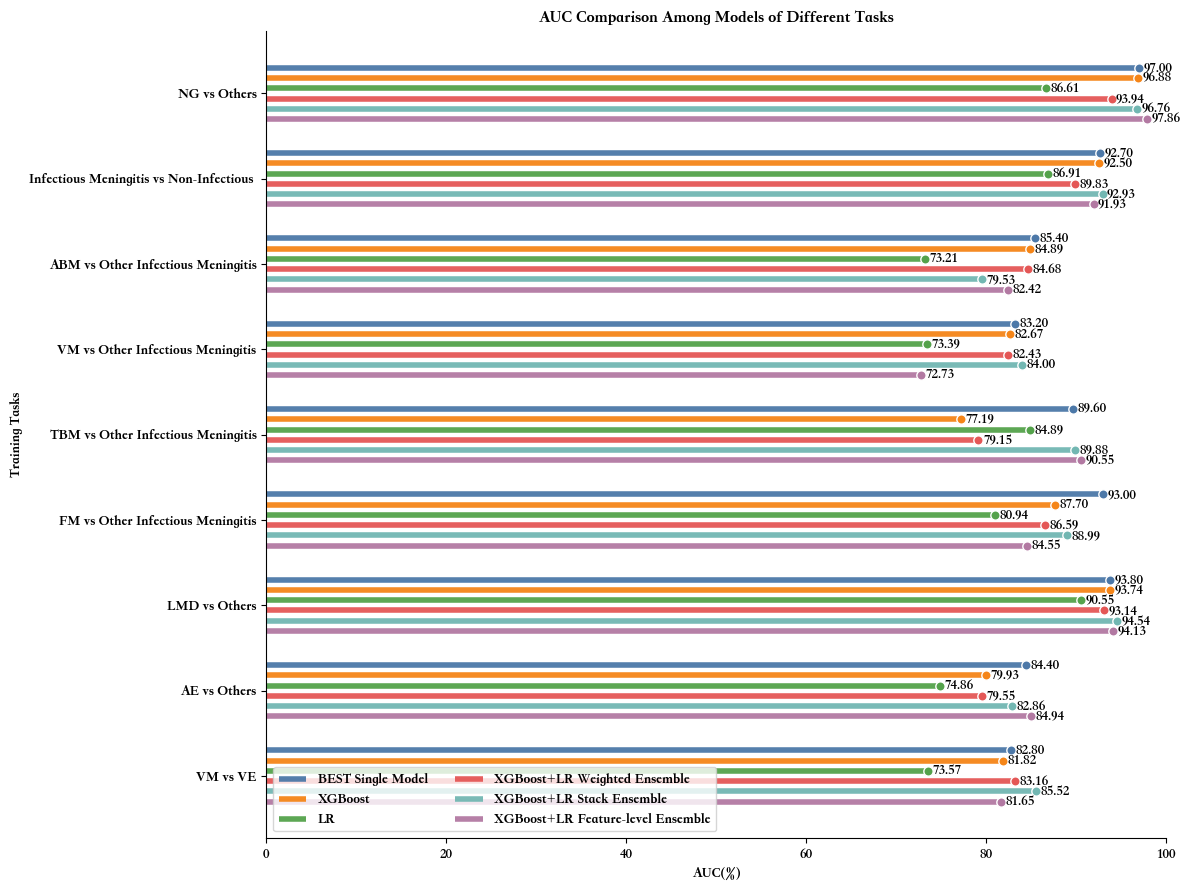

In [ ]:
#--------------------------------------------不同任务下模型对比 修改为横向柱状图-----------------------------------------------
df2 = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/单模型最优结果对比.xlsx")

singel_model = list(df2['血液203项+脑脊液19项'])

df3 = pd.read_excel("/Users/yanjieni/Desktop/projects/脑脊液/naojiye/模型训练结果7.xlsx",sheet_name=None)
singel_model2 = list(df3['XGBoost模型结果']['血液203项+脑脊液18项'])
singel_model3 = list(df3['LR模型结果']['血液203项+脑脊液18项'])
mixed_model1 = list(df3['LR+XGBoost1模型结果']['血液203项+脑脊液18项'])
mixed_model2 = list(df3['LR+XGBoost2模型结果']['血液203项+脑脊液18项'])
mixed_model3 = list(df3['LR+XGBoost3模型结果']['血液203项+脑脊液18项'])
singel_model2 = [round(x*100,2) for x in singel_model2]
singel_model3 = [round(x*100,2) for x in singel_model3]
mixed_model1 = [round(x*100,2) for x in mixed_model1]
mixed_model2 = [round(x*100,2) for x in mixed_model2]
mixed_model3 = [round(x*100,2) for x in mixed_model3]

data = {
    "任务": [
        "阴性vs其他", 
        "感染性vs非感染性", 
        "细菌性vs其他感染性", 
        "病毒性vs其他感染性",
        "结核性vs其他感染性", 
        "真菌性vs其他感染性", 
        "肿瘤性vs其他", 
        "自身免疫性vs其他", 
        "病毒性脑膜炎vs脑炎"
    ],
    "BEST Single Model": singel_model,
    "XGBoost": singel_model2,
    "LR": singel_model3,
    "XGBoost+LR Weighted Ensemble": mixed_model1,
    "XGBoost+LR Stack Ensemble": mixed_model2,
    "XGBoost+LR Feature-level Ensemble": mixed_model3,
}
data['任务'] = [y for x,y in task_trans.items()]

df = pd.DataFrame(data)

series = [
    "BEST Single Model",
    "XGBoost",
    "LR",
    "XGBoost+LR Weighted Ensemble",
    "XGBoost+LR Stack Ensemble",
    "XGBoost+LR Feature-level Ensemble",
]

tasks = df["任务"].tolist()
y0 = np.arange(len(tasks))[::-1]
dy = 0.12                # 同一任务内不同模型的垂直错位
marker_size = 45         # 圆点大小（点越大值越明显）
line_w = 4               # 线宽
xmax = 100               # AUC 最大刻度（一般 1.0）

fig, ax = plt.subplots(figsize=(12, 9))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]

for i, col in enumerate(series):
    yy = y0 + ((len(series)-1)-i - (len(series)-1)/2.0) * dy
    vals = df[col].to_numpy(dtype=float)

    ax.hlines(yy, 0, vals, linewidth=line_w, color=colors[i], alpha=0.95, label=col)
    ax.scatter(vals, yy, s=marker_size, color=colors[i], edgecolor="white", zorder=3)

    for x, y in zip(vals, yy):
        ax.text(x + 0.5, y, f"{x:.2f}", va="center", ha="left", fontsize=10)

# 设置标签和标题
ax.set_xlim(0, xmax)
ax.set_yticks(y0)
ax.set_yticklabels(tasks)
ax.set_xlabel("AUC(%)")
ax.set_ylabel("Training Tasks")
ax.set_title("AUC Comparison Among Models of Different Tasks")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')

# ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower left", ncol=2)
# plt.axis("auto")
plt.tight_layout()
plt.show()


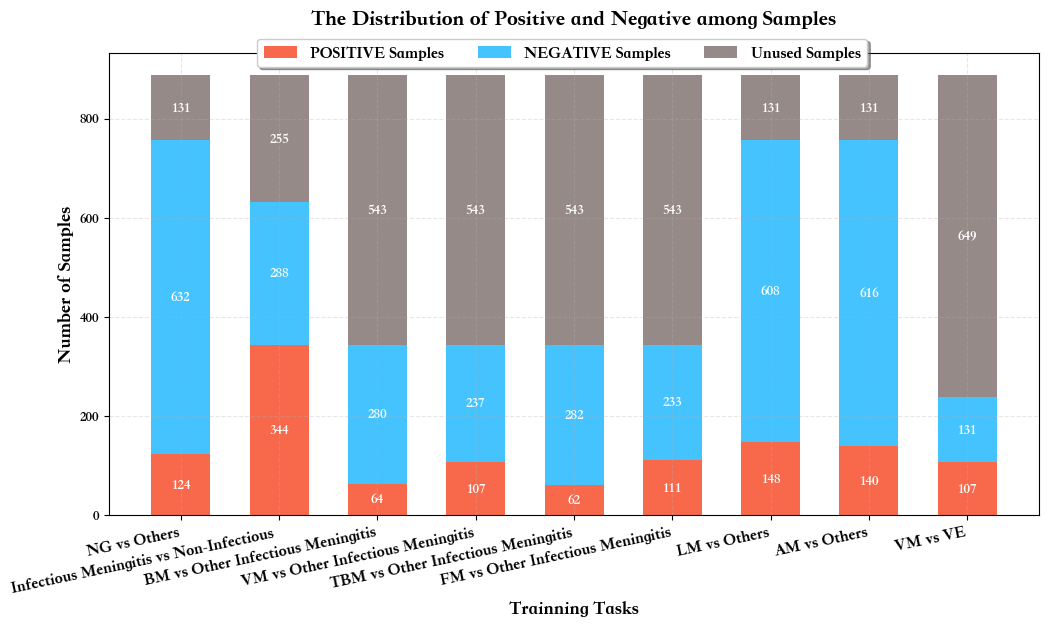

In [ ]:
# --------------------------------------------------数据信息柱状图1-------------------------------------------------------

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

labels = ['阴性\n(124)', '细菌性\n(64)', '病毒性\n(107)', '结核性\n(63)', 
          '真菌性\n(111)', '肿瘤性\n(149)', '自身免疫性\n(140)', '病毒性脑炎\n(131)']
sizes = [124, 64, 107, 63, 111, 149, 140, 131]

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性vs其他感染性': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性vs其他感染性': [[1,2,3,4], [2], [1,3,4]],
    '结核性vs其他感染性': [[1,2,3,4], [3], [1,2,4]],
    '真菌性vs其他感染性': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

data_detail = {
    '阴性组vs其他': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '感染性v非感染组': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '细菌性vs其他感染性': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '病毒性vs其他感染性': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '结核性vs其他感染性': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '真菌性vs其他感染性': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '肿瘤性vs其他': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '自身免疫性vs其他': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    '病毒性脑膜炎vs病毒性脑炎': {'正反例':{'正例':0,'反例':0,'未使用':0},'数据集分布':{'训练集':0,'验证集':0,'测试集':0}},
    }

for key, item in screen_data.items():
    # 筛选需要的组别
    selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    data_detail[key]['正反例']['正例'] = len(X_1)
    data_detail[key]['正反例']['反例'] = len(X_2)
    data_detail[key]['正反例']['未使用'] = len(pd.read_csv(data_path))- len(X_1) - len(X_2)
    data_detail[key]['数据集分布']['训练集'] = len(X_train)
    data_detail[key]['数据集分布']['验证集'] = len(X_val)
    data_detail[key]['数据集分布']['测试集'] = len(X_test)

data_detail1 = data_detail.copy()
list(data_detail1.keys())
data_detail = {task_trans1[key]:item for key, item in data_detail1.items()}
    
fig, ax = plt.subplots(figsize=(12, 6))

combinations = list(data_detail.keys())

for key, item in data_detail.items():
    positive_data = [data_detail[k]['正反例']['正例'] for k in data_detail]
    negative_data = [data_detail[k]['正反例']['反例'] for k in data_detail]
    no_use_data = [data_detail[k]['正反例']['未使用'] for k in data_detail]
    train_data = [data_detail[k]['数据集分布']['训练集'] for k in data_detail]
    val_data = [data_detail[k]['数据集分布']['验证集'] for k in data_detail]
    test_data = [data_detail[k]['数据集分布']['测试集'] for k in data_detail]

x_pos = np.arange(len(combinations))
width = 0.6

# 创建堆叠柱状图
bars1 = ax.bar(x_pos, positive_data, width, label='POSITIVE Samples', color="#F7431F", alpha=0.8)
bars2 = ax.bar(x_pos, negative_data, width, bottom=positive_data, label='NEGATIVE Samples', color="#17B5FF", alpha=0.8)
bars3 = ax.bar(x_pos, no_use_data, width,  bottom=[x + y for x, y in zip(positive_data, negative_data)],label='Unused Samples', color="#7C6D6A", alpha=0.8)
# bars4 = ax.bar(x_pos, val_data, width, bottom=positive_data, label='验证集', color="#17B5FF", alpha=0.8)
# bars5 = ax.bar(x_pos, test_data, width, bottom=positive_data, label='测试集', color="#1FF735", alpha=0.8)

ax.set_xlabel('Trainning Tasks', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('The Distribution of Positive and Negative among Samples', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(combinations, rotation=12, ha='right', fontsize=12)
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.15, 1.05),ncol=3)
ax.grid(True, alpha=0.3, linestyle='--')

# 添加数值标签
for i, (b, c, d) in enumerate(zip(positive_data, negative_data, no_use_data)):
    if b > 0:
        ax.text(i, b/2, str(b), ha='center', va='center', fontweight='bold', color='white')
    if c > 0:
        ax.text(i, b + c/2, str(c), ha='center', va='center', fontweight='bold', color='white')
    if d > 0:
        ax.text(i, b + c + d/2, str(d), ha='center', va='center', fontweight='bold', color='white')


plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/样本正反例分布.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)

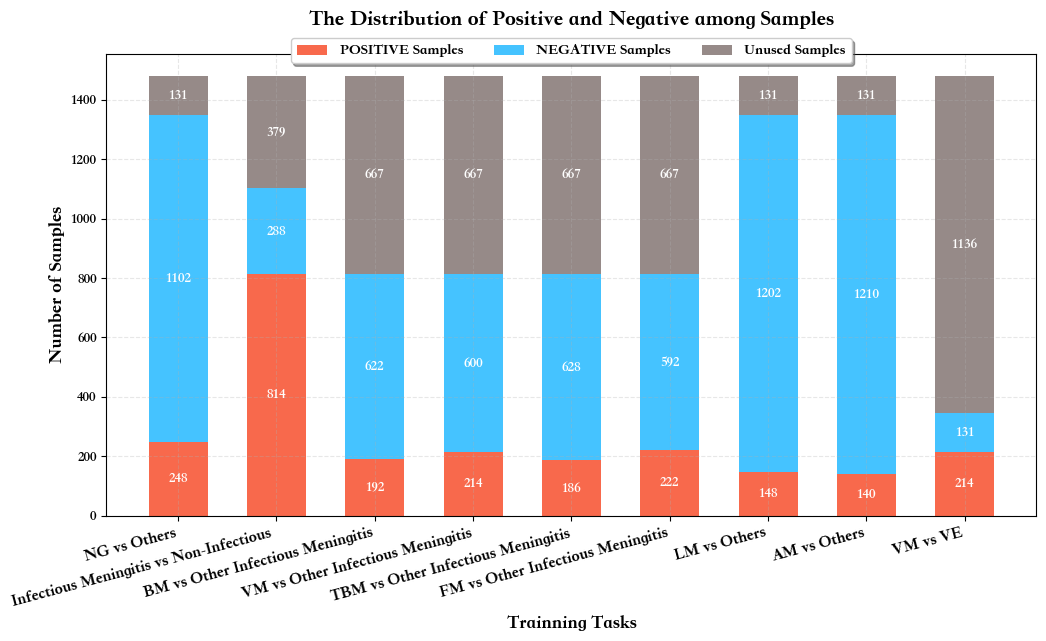

In [ ]:
# --------------------------------------------------数据信息柱状图2-------------------------------------------------------

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

labels = ['阴性\n(124)', '细菌性\n(64)', '病毒性\n(107)', '结核性\n(63)', 
          '真菌性\n(111)', '肿瘤性\n(149)', '自身免疫性\n(140)', '病毒性脑炎\n(131)']
sizes = [124, 64, 107, 63, 111, 149, 140, 131]

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性vs其他感染性': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性vs其他感染性': [[1,2,3,4], [2], [1,3,4]],
    '结核性vs其他感染性': [[1,2,3,4], [3], [1,2,4]],
    '真菌性vs其他感染性': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

# data_detail = {
#     '阴性组vs其他': {'正反例':{'正例':248,'反例':1102,'未使用':131},'数据集分布':{'训练集':810,'验证集':270,'测试集':270}},
#     '感染性v非感染组': {'正反例':{'正例':814,'反例':288,'未使用':379},'数据集分布':{'训练集':662,'验证集':220,'测试集':220}},
#     '细菌性vs其他感染性': {'正反例':{'正例':192,'反例':622,'未使用':667},'数据集分布':{'训练集':488,'验证集':163,'测试集':163}},
#     '病毒性vs其他感染性': {'正反例':{'正例':214,'反例':600,'未使用':667},'数据集分布':{'训练集':488,'验证集':163,'测试集':163}},
#     '结核性vs其他感染性': {'正反例':{'正例':186,'反例':628,'未使用':667},'数据集分布':{'训练集':488,'验证集':163,'测试集':163}},
#     '真菌性vs其他感染性': {'正反例':{'正例':222,'反例':592,'未使用':667},'数据集分布':{'训练集':488,'验证集':163,'测试集':163}},
#     '肿瘤性vs其他': {'正反例':{'正例':148,'反例':1202,'未使用':131},'数据集分布':{'训练集':810,'验证集':270,'测试集':270}},
#     '自身免疫性vs其他': {'正反例':{'正例':140,'反例':1210,'未使用':131},'数据集分布':{'训练集':810,'验证集':270,'测试集':270}},
#     '病毒性脑膜炎vs病毒性脑炎': {'正反例':{'正例':214,'反例':131,'未使用':1136},'数据集分布':{'训练集':207,'验证集':69,'测试集':69}},
#     }

for key, item in screen_data.items():
    # 筛选需要的组别
    selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    data_detail[key]['正反例']['正例'] = len(X_1)
    data_detail[key]['正反例']['反例'] = len(X_2)
    data_detail[key]['正反例']['未使用'] = len(pd.read_csv(data_path))- len(X_1) - len(X_2)
    data_detail[key]['数据集分布']['训练集'] = len(X_train)
    data_detail[key]['数据集分布']['验证集'] = len(X_val)
    data_detail[key]['数据集分布']['测试集'] = len(X_test)

data_detail1 = data_detail.copy()
list(data_detail1.keys())
data_detail = {task_trans1[key]:item for key, item in data_detail1.items()}
    
fig, ax = plt.subplots(figsize=(12, 6))

combinations = list(data_detail.keys())

for key, item in data_detail.items():
    positive_data = [data_detail[k]['正反例']['正例'] for k in data_detail]
    negative_data = [data_detail[k]['正反例']['反例'] for k in data_detail]
    no_use_data = [data_detail[k]['正反例']['未使用'] for k in data_detail]
    train_data = [data_detail[k]['数据集分布']['训练集'] for k in data_detail]
    val_data = [data_detail[k]['数据集分布']['验证集'] for k in data_detail]
    test_data = [data_detail[k]['数据集分布']['测试集'] for k in data_detail]

x_pos = np.arange(len(combinations))
width = 0.6

# 创建堆叠柱状图
bars1 = ax.bar(x_pos, positive_data, width, label='POSITIVE Samples', color="#F7431F", alpha=0.8)
bars2 = ax.bar(x_pos, negative_data, width, bottom=positive_data, label='NEGATIVE Samples', color="#17B5FF", alpha=0.8)
bars3 = ax.bar(x_pos, no_use_data, width,  bottom=[x + y for x, y in zip(positive_data, negative_data)],label='Unused Samples', color="#7C6D6A", alpha=0.8)
# bars4 = ax.bar(x_pos, val_data, width, bottom=positive_data, label='验证集', color="#17B5FF", alpha=0.8)
# bars5 = ax.bar(x_pos, test_data, width, bottom=positive_data, label='测试集', color="#1FF735", alpha=0.8)

ax.set_xlabel('Trainning Tasks', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('The Distribution of Positive and Negative among Samples', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(combinations, rotation=15, ha='right', fontsize=12)
ax.legend(loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.19, 1.05),ncol=3)
ax.grid(True, alpha=0.3, linestyle='--')

# 添加数值标签
for i, (b, c, d) in enumerate(zip(positive_data, negative_data, no_use_data)):
    if b > 0:
        ax.text(i, b/2, str(b), ha='center', va='center', fontweight='bold', color='white')
    if c > 0:
        ax.text(i, b + c/2, str(c), ha='center', va='center', fontweight='bold', color='white')
    if d > 0:
        ax.text(i, b + c + d/2, str(d), ha='center', va='center', fontweight='bold', color='white')


plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/样本正反例分布.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)

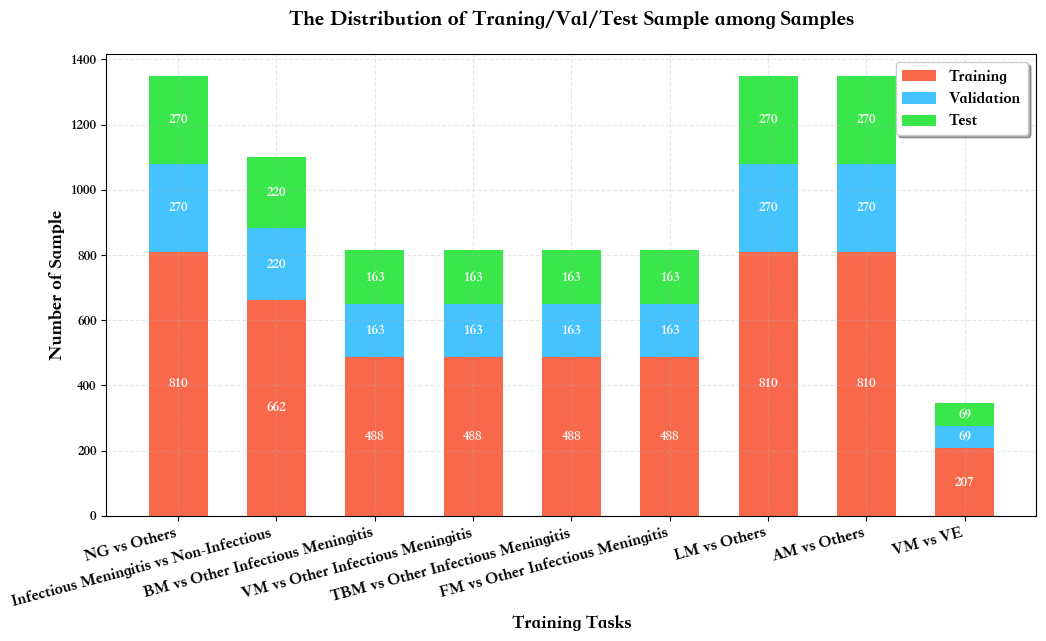

In [ ]:
# --------------------------------------------------数据信息柱状图3-------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

combinations = list(data_detail.keys())

for key, item in data_detail.items():
    positive_data = [data_detail[k]['正反例']['正例'] for k in data_detail]
    negative_data = [data_detail[k]['正反例']['反例'] for k in data_detail]
    train_data = [data_detail[k]['数据集分布']['训练集'] for k in data_detail]
    val_data = [data_detail[k]['数据集分布']['验证集'] for k in data_detail]
    test_data = [data_detail[k]['数据集分布']['测试集'] for k in data_detail]

x_pos = np.arange(len(combinations))
width = 0.6

# 创建堆叠柱状图
# bars1 = ax.bar(x_pos, positive_data, width, label='正例', color="#F7431F", alpha=0.8)
# bars2 = ax.bar(x_pos, negative_data, width, bottom=positive_data, label='反例', color="#17B5FF", alpha=0.8)
bars3 = ax.bar(x_pos, train_data, width, label='Training', color="#F7431F", alpha=0.8)
bars4 = ax.bar(x_pos, val_data, width, bottom=train_data, label='Validation', color="#17B5FF", alpha=0.8)
bars5 = ax.bar(x_pos, test_data, width, bottom=[x + y for x, y in zip(train_data, val_data)], label='Test', color="#07E21D", alpha=0.8)


ax.set_xlabel('Training Tasks', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Sample', fontsize=14, fontweight='bold')
ax.set_title('The Distribution of Traning/Val/Test Sample among Samples', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(combinations, rotation=15, ha='right', fontsize=12)
ax.legend(loc='upper right', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')

# 添加数值标签
for i, (b, c, d) in enumerate(zip(train_data, val_data, test_data)):
    if b > 0:
        ax.text(i, b/2, str(b), ha='center', va='center', fontweight='bold', color='white')
    if c > 0:
        ax.text(i, b + c/2, str(c), ha='center', va='center', fontweight='bold', color='white')
    if d > 0:
        ax.text(i, b + c + d/2, str(d), ha='center', va='center', fontweight='bold', color='white')


plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/distribution_train_val_test_histogram.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)


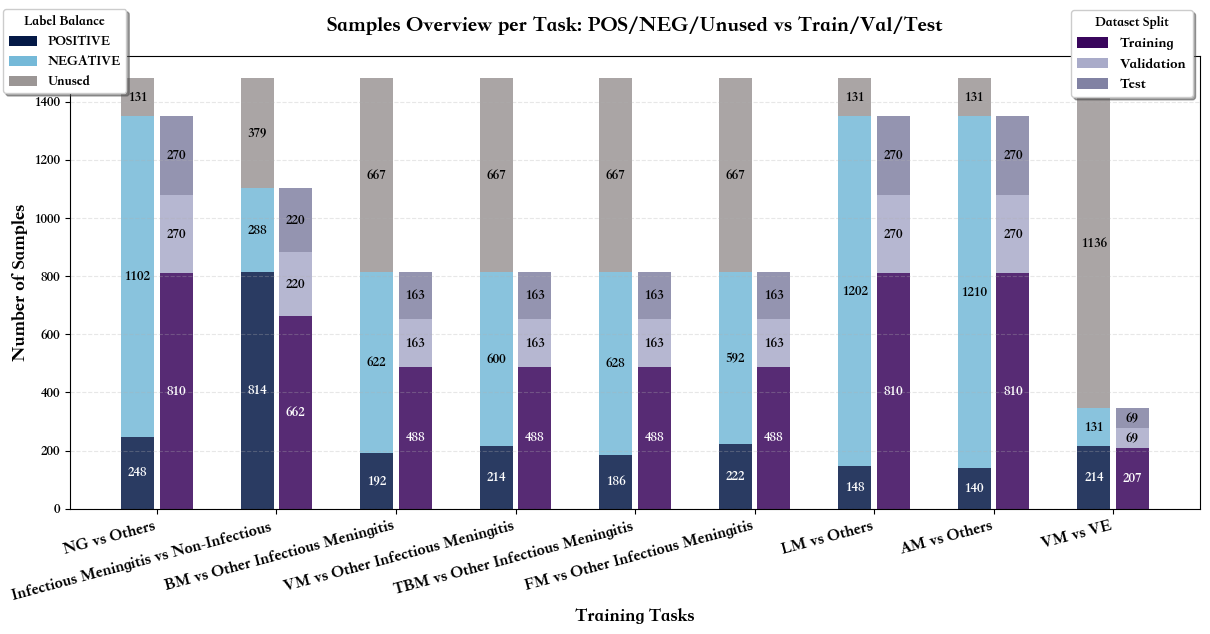

In [ ]:

# --------------------------------------------------数据信息柱状图3-------------------------------------------------------

combinations = list(data_detail.keys())

positive_data = np.array([data_detail[k]['正反例']['正例'] for k in data_detail])
negative_data = np.array([data_detail[k]['正反例']['反例'] for k in data_detail])
no_use_data   = np.array([data_detail[k]['正反例']['未使用'] for k in data_detail])

train_data = np.array([data_detail[k]['数据集分布']['训练集'] for k in data_detail])
val_data   = np.array([data_detail[k]['数据集分布']['验证集'] for k in data_detail])
test_data  = np.array([data_detail[k]['数据集分布']['测试集'] for k in data_detail])

x_pos = np.arange(len(combinations))*0.9
bar_width = 0.25                     # 每组内单根柱子的宽度
gap = 0.04                            # 组内两柱之间的小间隙（可选）

left_bar_x  = x_pos - (bar_width/2 + gap/2)   # 左侧柱（正/反/未用）
right_bar_x = x_pos + (bar_width/2 + gap/2)   # 右侧柱（Train/Val/Test）

# —— 两套不同的配色 —— 
palette_lr = {"POS":"#041946", "NEG":"#75B9D8", "UNU":"#9B9695"}   # 左柱：正反未用
palette_tvt = {"TR":"#39065C", "VA":"#A9ABC9", "TE":"#8182A3"}     # 右柱：Train/Val/Test

fig, ax = plt.subplots(figsize=(12.5, 6.5))

# —— 左侧柱：正/反/未用（堆叠）——
bars_pos = ax.bar(left_bar_x, positive_data, width=bar_width, label='POSITIVE', color=palette_lr["POS"], alpha=0.85)
bars_neg = ax.bar(left_bar_x, negative_data, width=bar_width, bottom=positive_data, label='NEGATIVE', color=palette_lr["NEG"], alpha=0.85)
bars_unu = ax.bar(left_bar_x, no_use_data,   width=bar_width, bottom=positive_data+negative_data, label='Unused',  color=palette_lr["UNU"], alpha=0.85)

# —— 右侧柱：Train/Val/Test（堆叠）——
bars_tr = ax.bar(right_bar_x, train_data, width=bar_width, label='Training',   color=palette_tvt["TR"], alpha=0.85)
bars_va = ax.bar(right_bar_x, val_data,   width=bar_width, bottom=train_data,  label='Validation', color=palette_tvt["VA"], alpha=0.85)
bars_te = ax.bar(right_bar_x, test_data,  width=bar_width, bottom=train_data+val_data, label='Test', color=palette_tvt["TE"], alpha=0.85)

# —— 外观设置 —— 
ax.set_xlabel('Training Tasks', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('Samples Overview per Task: POS/NEG/Unused vs Train/Val/Test', fontsize=16, fontweight='bold', pad=18)
ax.set_xticks(x_pos)
ax.set_xticklabels(combinations, rotation=15, ha='right', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# —— 数值标签（居中到各堆叠块）——
def annotate_stacks(x, a, b=None, c=None):
    # a, b, c 为同长度数组，分别是堆叠的第一、第二、第三层（允许 b 或 c 为 None）
    if b is None: b = np.zeros_like(a)
    if c is None: c = np.zeros_like(a)
    for i in range(len(x)):
        if a[i] > 0:
            ax.text(x[i], a[i]/2, str(int(a[i])), ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        if b[i] > 0:
            ax.text(x[i], a[i] + b[i]/2, str(int(b[i])), ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        if c[i] > 0:
            ax.text(x[i], a[i] + b[i] + c[i]/2, str(int(c[i])), ha='center', va='center', fontsize=10, fontweight='bold', color='black')

annotate_stacks(left_bar_x,  positive_data, negative_data, no_use_data)
annotate_stacks(right_bar_x, train_data,   val_data,      test_data)

# —— 两套图例分别显示，左右各一个 —— 
legend_left  = [Patch(facecolor=palette_lr["POS"], label='POSITIVE'),
                Patch(facecolor=palette_lr["NEG"], label='NEGATIVE'),
                Patch(facecolor=palette_lr["UNU"], label='Unused')]
legend_right = [Patch(facecolor=palette_tvt["TR"], label='Training'),
                Patch(facecolor=palette_tvt["VA"], label='Validation'),
                Patch(facecolor=palette_tvt["TE"], label='Test')]

leg1 = ax.legend(handles=legend_left,  loc='upper left',  fontsize=10, frameon=True, fancybox=True, shadow=True, title='Label Balance', bbox_to_anchor=(-0.065, 1.12), ncol=1)
ax.add_artist(leg1)  # 保留第一个图例
ax.legend(handles=legend_right, loc='upper right', fontsize=11, frameon=True, fancybox=True, shadow=True, title='Dataset Split', bbox_to_anchor=(1, 1.12))

plt.tight_layout()
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/样本概览_并列堆叠.png',
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none', pad_inches=0.2)
plt.show()


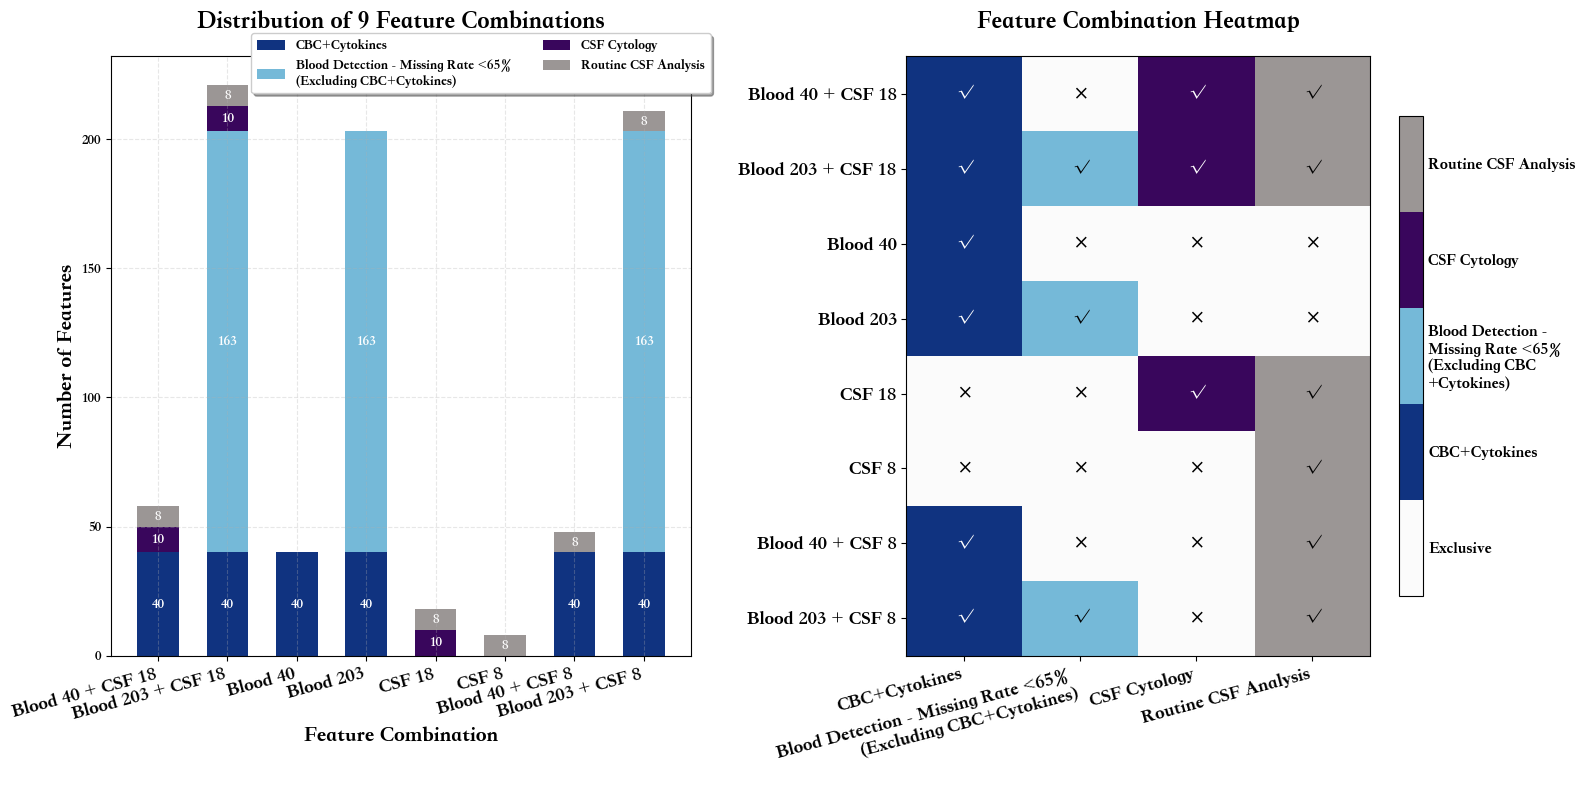

特征组合对比图已生成


In [ ]:
# --------------------------------------------------特征组合信息-------------------------------------------------------


# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建特征组合数据
feature_combinations = {
    '血液40项+脑脊液18项': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':0, '脑脊液细胞形态学': 10, '脑脊液常规': 8, '总计': 58},
    '血液203项+脑脊液18项': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':163, '脑脊液细胞形态学': 10, '脑脊液常规': 8, '总计': 221},
    '血液40项': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':0, '脑脊液细胞形态学': 0, '脑脊液常规': 0, '总计': 40},
    '血液203项': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':163, '脑脊液细胞形态学': 0, '脑脊液常规': 0, '总计': 203},
    '脑脊液18项': {'血常规': 0, '缺失率低于65的血液检查\n（除血常规）':0, '脑脊液细胞形态学': 10, '脑脊液常规': 8, '总计': 18},
    '脑脊液8项': {'血常规': 0, '缺失率低于65的血液检查\n（除血常规）':0, '脑脊液细胞形态学': 0, '脑脊液常规': 8, '总计': 8},
    '血液40项+脑脊液8项': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':0, '脑脊液细胞形态学': 0, '脑脊液常规': 8, '总计': 48},
    '血液203+脑脊液8': {'血常规': 40, '缺失率低于65的血液检查\n（除血常规）':163, '脑脊液细胞形态学': 0, '脑脊液常规': 8, '总计': 211},
}
feature_combinations1 = feature_combinations.copy()
feature_combinations = {feature_comb_trans[key]:item for key, item in feature_combinations1.items()}

# 创建可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 左图：特征数量堆叠柱状图
combinations = list(feature_combinations.keys())
blood_features1 = [feature_combinations[k]['血常规'] for k in combinations]
blood_features2 = [feature_combinations[k]['缺失率低于65的血液检查\n（除血常规）'] for k in combinations]
csf_features1 = [feature_combinations[k]['脑脊液细胞形态学'] for k in combinations]
csf_features2 = [feature_combinations[k]['脑脊液常规'] for k in combinations]
combine1 = [x + y for x, y in zip(blood_features1, blood_features2)]
combine2 = [x + y for x, y in zip(combine1, csf_features1)]

x_pos = np.arange(len(combinations))
width = 0.6

# 创建堆叠柱状图
bars1 = ax1.bar(x_pos, blood_features1, width, label='CBC+Cytokines', color="#103380", alpha=1)
bars2 = ax1.bar(x_pos, blood_features2, width, bottom=blood_features1, label='Blood Detection - Missing Rate <65% \n(Excluding CBC+Cytokines)', color="#75B9D8", alpha=1)
bars2 = ax1.bar(x_pos, csf_features1, width, bottom=combine1, label='CSF Cytology', color="#39065C", alpha=1)
bars2 = ax1.bar(x_pos, csf_features2, width, bottom=combine2, label='Routine CSF Analysis', color="#9B9695", alpha=1)

ax1.set_xlabel('Feature Combination', fontsize=16, fontweight='bold')
ax1.set_ylabel('Number of Features', fontsize=16, fontweight='bold')
ax1.set_title('Distribution of 9 Feature Combinations', fontsize=18, fontweight='bold', pad=20)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(combinations, rotation=15, ha='right', fontsize=14,fontweight='bold')
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, bbox_to_anchor=(0.23, 1.05), ncol=2)
ax1.grid(True, alpha=0.3, linestyle='--')

# 添加数值标签
for i, (b, c, d, e) in enumerate(zip(blood_features1, blood_features2, csf_features1, csf_features2)):
    if b > 0:
        ax1.text(i, b/2, str(b), ha='center', va='center', fontweight='bold', color='white')
    if c > 0:
        ax1.text(i, b + c/2, str(c), ha='center', va='center', fontweight='bold', color='white')
    if d > 0:
        ax1.text(i, b + c + d/2, str(d), ha='center', va='center', fontweight='bold', color='white')
    if e > 0:
        ax1.text(i, b + c + d + e/2, str(e), ha='center', va='center', fontweight='bold', color='white')

# 右图：特征覆盖率热力图
coverage_data = []
# feature_types = ['血常规', '特征包含缺失率低于65的血液检查\n（除血常规）', '脑脊液细胞形态学', '脑脊液常规']
# combinations_simple = ['特征组合1', '特征组合2', '特征组合3', '特征组合4', '特征组合5', '特征组合6', '特征组合7', '特征组合8']
feature_types = ["CBC+Cytokines", "Blood Detection - Missing Rate <65% \n(Excluding CBC+Cytokines)", "CSF Cytology", "Routine CSF Analysis"]
combinations_simple = [y for x,y in feature_comb_trans.items()][:-1] 

# 构建覆盖率矩阵
coverage_matrix = np.array([
    [1, 0, 3, 4],  # C1
    [1, 2, 3, 4],  # C2
    [1, 0, 0, 0],  # C3
    [1, 2, 0, 0],  # C4
    [0, 0, 3, 4],  # C5
    [0, 0, 0, 4],  # C6
    [1, 0, 0, 4],  # C7
    [1, 2, 0, 4],  # C8
])
# palette_lr = {"POS":"#041946", "NEG":"#75B9D8", "UNU":"#9B9695"}   # 左柱：正反未用
# palette_tvt = {"TR":"#39065C", "VA":"#A9ABC9", "TE":"#8182A3"}     # 右柱：Train/Val/Test
cmap = ListedColormap(["#fbfbfb", "#103380", '#75B9D8', '#39065C', "#9B9695"])  # 索引0,1,2的颜色

im = ax2.imshow(coverage_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=4)
ax2.set_xticks(range(len(feature_types)))
ax2.set_yticks(range(len(combinations_simple)))
ax2.set_xticklabels(feature_types, rotation=15, ha='right', fontsize=14, fontweight='bold')
ax2.set_yticklabels(combinations_simple, fontsize=14, fontweight='bold')
ax2.set_title('Feature Combination Heatmap', fontsize=18, fontweight='bold', pad=20)


# 添加文本标注
for i in range(len(combinations_simple)):
    for j in range(len(feature_types)):
        text = '√' if coverage_matrix[i, j] == 1 or coverage_matrix[i, j] == 2 or coverage_matrix[i, j] == 3 or coverage_matrix[i, j] == 4 else '×'
        color = 'white' if coverage_matrix[i, j] == 1 or coverage_matrix[i, j] == 3 else 'black'
        ax2.text(j, i, text, ha='center', va='center', color=color, fontweight='bold', fontsize=12)

# 添加颜色条
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
# cbar.set_ticks(np.arange(4) + 0.5)
cbar.set_ticks([0.4, 1.2, 2, 2.8, 3.6])
cbar.set_ticklabels(['Exclusive', "CBC+Cytokines", "Blood Detection - \nMissing Rate <65% \n(Excluding CBC\n+Cytokines)", "CSF Cytology", "Routine CSF Analysis"],fontsize=12)
cbar.ax.tick_params(which='both', length=0)  # 去掉刻度线


plt.tight_layout()

plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/distribution_features_histogram.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)

plt.show()

print("特征组合对比图已生成")

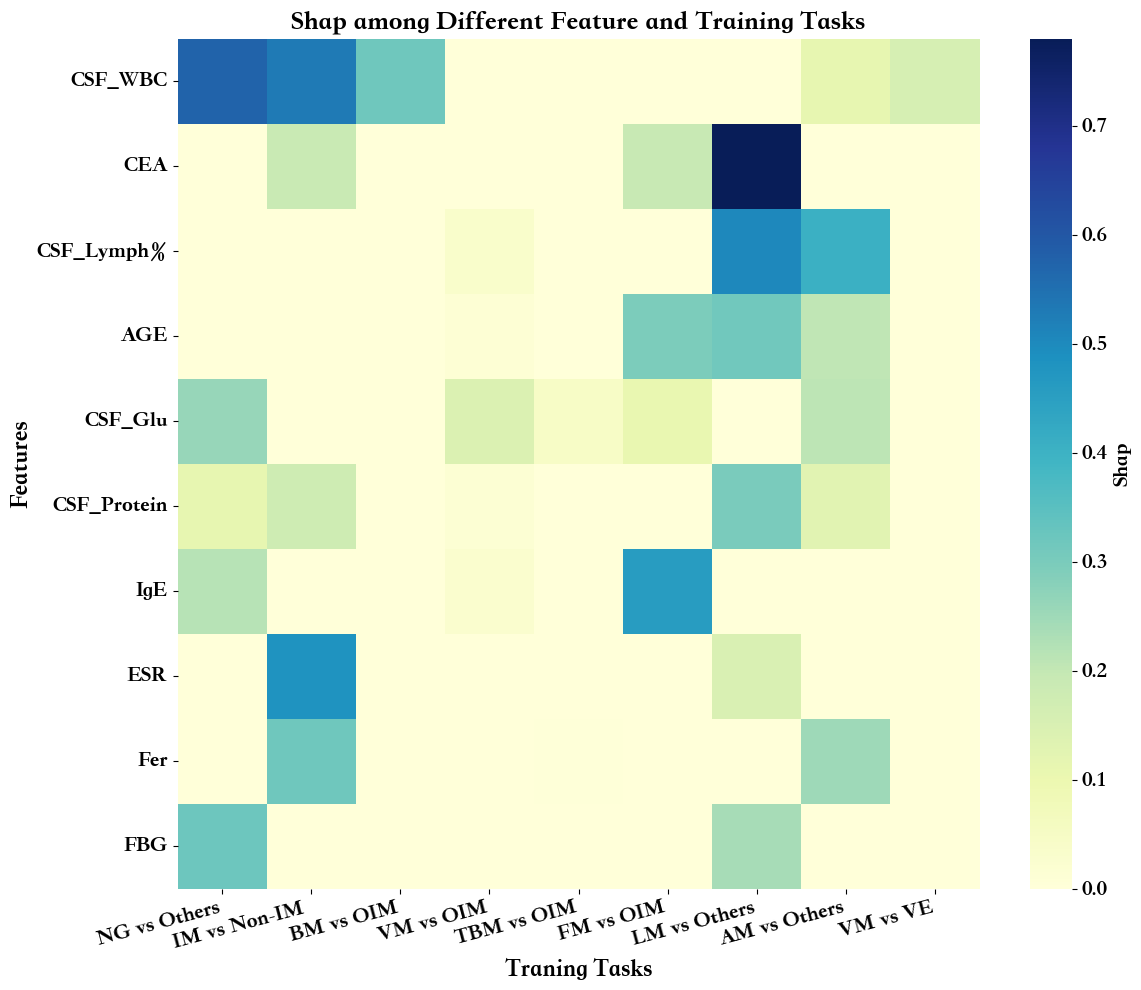

In [ ]:
# --------------------------------------------------特征重要性热力图-------------------------------------------------------

import os
path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/shap/'
tasks = ['阴性组vs其他/', '感染性脑膜炎v非感染组/', '细菌性脑膜炎vs其他感染性脑膜炎/', '病毒性脑膜炎vs其他感染性脑膜炎/', '结核性脑膜炎vs其他感染性脑膜炎/', '真菌性脑膜炎vs其他感染性脑膜炎/', '肿瘤性脑膜炎vs其他/', 
         '自身免疫性脑膜炎vs其他/', '病毒性脑膜炎vs病毒性脑炎/']
data = os.listdir(path+tasks[0])
data = 'Dataset2_shap.csv'
df_all = pd.read_csv(path+tasks[0]+data)

for task in tasks:
    df1 = pd.read_csv(path+task+data)
    
    df1 = df1.rename(columns={'mean_abs_shap': task[:-1]})
    
    if task == '阴性组vs其他/':
        df_all = df1[['feature',task[:-1]]]
    else:
        df_all = pd.merge(df_all, df1[['feature',task[:-1]]], how='outer', on='feature')
df_all = df_all.rename(columns={'feature': '特征'})
df_all = df_all.fillna(0)
df_all = df_all.set_index('特征')
df_all = df_all.rename(index={'血_葡萄糖空腹_定量': '血_葡萄糖[空腹]_定量'})
df_all = df_all.rename(index={'血_肌酸激酶.MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'})

df_all['sum'] = df_all.sum(axis=1)
df_all = df_all.sort_values('sum', ascending=False)

df_all = df_all.drop(columns = ['sum'])
df_all = df_all.rename(columns={'感染性脑膜炎v非感染组': '感染性v非感染组' , '细菌性脑膜炎vs其他感染性脑膜炎': '细菌性vs其他感染性', '病毒性脑膜炎vs其他感染性脑膜炎': '病毒性vs其他感染性', 
                                '结核性脑膜炎vs其他感染性脑膜炎': '结核性vs其他感染性', '真菌性脑膜炎vs其他感染性脑膜炎': '真菌性vs其他感染性', '肿瘤性脑膜炎vs其他': '肿瘤性vs其他', '自身免疫性脑膜炎vs其他': '自身免疫性vs其他'})
df_all_10 = df_all.head(10)

trans_df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/项目英文缩写与全称.xlsx')
trans_dict = {}

for index, row in trans_df.iterrows():
    trans_dict[row['中文项目名称']] = row['英文缩写']


new_index = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(df_all_10.index)]
# new_index
# df_all_10.index = new_index

index_trans = [trans_dict[x] for x in new_index]
# df_all_10_1 = df_all_10.copy()
df_all_10.index = index_trans
df_all_10 = df_all_10.rename(columns=task_trans3)

# 设置画布大小
plt.figure(figsize=(12, 10))

# 绘制热力图
ax = sns.heatmap(df_all_10, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Shap'})
# sns.heatmap(df_all, fmt=".2f", cmap="RdBu_r", cbar_kws={'label': 'AUC值'})
cbar = ax.collections[0].colorbar  # 取得 colorbar
cbar.ax.tick_params(labelsize=16)  # 刻度字号
cbar.ax.set_ylabel('Shap', fontsize=16)  # 轴标签字号

# 标题和标签
plt.title("Shap among Different Feature and Training Tasks", fontsize=20, fontweight="bold")
plt.xlabel("Traning Tasks", fontsize=18, fontweight="bold")
plt.ylabel("Features", fontsize=18, fontweight="bold")
plt.xticks(rotation=15, ha='right', fontsize=16)
plt.yticks(rotation=0, fontsize=16)

plt.tight_layout()
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/heatmap.png')
plt.show()

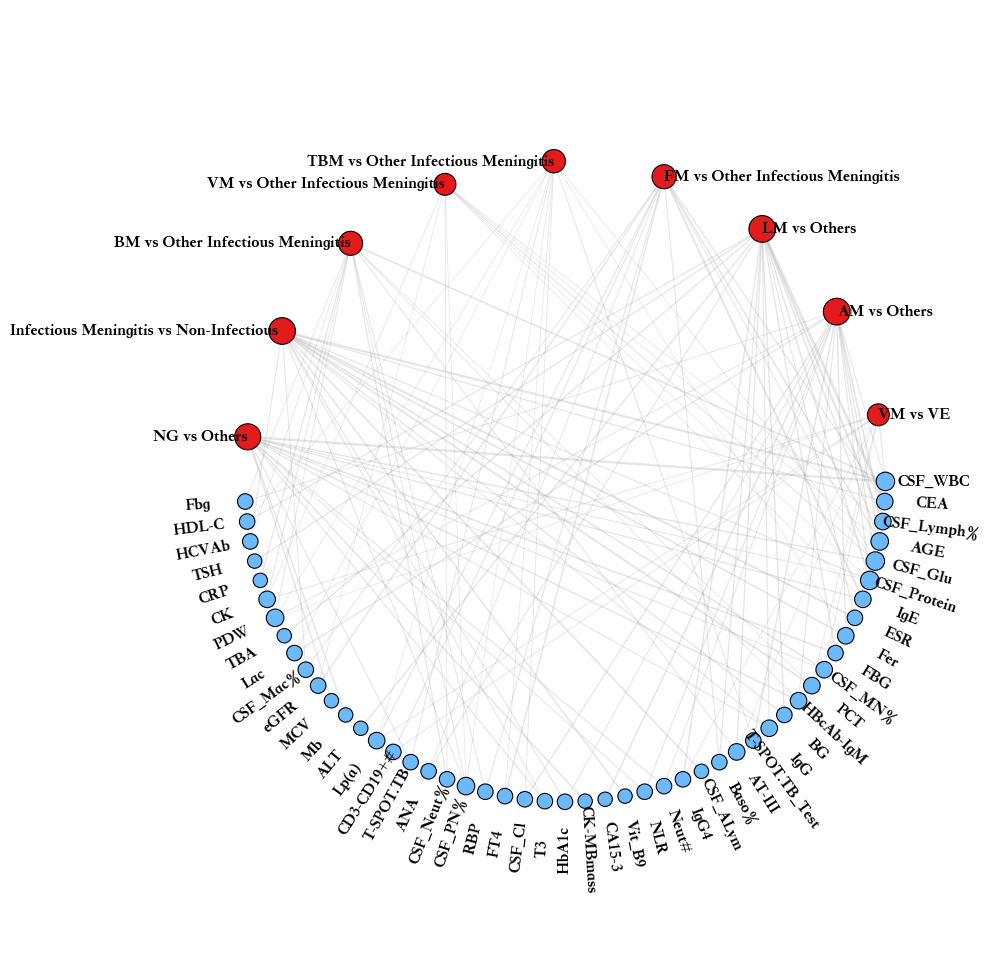

In [ ]:
# --------------------------------------------------特征重要性网络图-------------------------------------------------------

df_all_50 = df_all.head(50)


new_index_1 = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(df_all_50.index)]
# new_index
# df_all_10.index = new_index

index_trans_1 = [trans_dict[x] for x in new_index_1]
# df_all_10_1 = df_all_10.copy()
df_all_50.index = index_trans_1
task_trans = {
    "阴性组vs其他": "NG vs Others",
    "感染性v非感染组": "Infectious Meningitis vs Non-Infectious ",
    "细菌性vs其他感染性": "BM vs Other Infectious Meningitis",
    "病毒性vs其他感染性": "VM vs Other Infectious Meningitis",
    "结核性vs其他感染性": "TBM vs Other Infectious Meningitis",
    "真菌性vs其他感染性": "FM vs Other Infectious Meningitis",
    "肿瘤性vs其他": "LM vs Others",
    "自身免疫性vs其他": "AM vs Others",
    "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
}

df_all_50 = df_all_50.rename(columns=task_trans)

edges = []
left_nodes = df_all_50.columns
right_nodes = df_all_50.index
for c in left_nodes:
    for r in right_nodes:
        edges.append([c,r, df_all_50[c][r]])
df_edges = pd.DataFrame(edges, columns=["left","right","weight"])   # 如果你已有表，直接替换这行
THRESH = 0.0
df_edges = df_edges[df_edges["weight"].fillna(-np.inf) > THRESH]

# ===== 2) 建图 =====
G = nx.Graph()
G.add_nodes_from(left_nodes,  bipartite=0, group="left")
G.add_nodes_from(right_nodes, bipartite=1, group="right")

# 只保留跨组边（稳妥起见）
for _, row in df_edges.iterrows():
    u, v = row["left"], row["right"]
    if u in left_nodes and v in right_nodes:
        G.add_edge(u, v, weight=row.get("weight", 1.0))

# 节点度数 -> 大小
deg = dict(G.degree())
node_sizes = {n: (180 + 35*deg[n]) for n in G.nodes()}  # 适度放大

# ===== 3) 自定义“半圆对称”布局（上红、下蓝）=====
R = 1.0  # 圆半径
# 上半圈：从左到右（180° -> 0°）
# angles_left  = np.linspace(np.pi, 0.0, len(left_nodes), endpoint=False)
theta = np.deg2rad(8) 
angles_left = np.linspace(np.pi, 0.0, len(left_nodes), endpoint=False) - theta
# 下半圈：从右到左（ 0° -> -180°）
angles_right = np.linspace(0.0, -np.pi, len(right_nodes), endpoint=False)


pos = {}
for a, n in zip(angles_left, left_nodes):
    pos[n] = (R*np.cos(a), R*np.sin(a))
for a, n in zip(angles_right, right_nodes):
    pos[n] = (R*np.cos(a), R*np.sin(a))

# ===== 4) 绘图样式 =====
plt.figure(figsize=(10,10))
# 先画边：大量边时用低alpha与细线
edge_w = [G[u][v].get("weight",1.0) for u,v in G.edges()]
# 归一化到 [0.5, 2.0] 映射到线宽
if len(edge_w):
    w = np.array(edge_w, dtype=float)
    den = np.ptp(w)                          # 等价于 w.max() - w.min()
    w = 0.5 + 1.5 * (w - w.min()) / (den if den > 0 else 1.0)
else:
    w = 1.0
nx.draw_networkx_edges(
    G, pos,
    width=w if hasattr(w, "__len__") else 1.0,
    edge_color="#9a9a9a",
    alpha=0.25
)

# 再画节点（分组着色）
left_color, right_color = "#e41a1c", "#6bb9ff"
nx.draw_networkx_nodes(
    G, pos,
    nodelist=left_nodes,
    node_color=left_color, edgecolors="black",
    linewidths=0.8,
    node_size=[node_sizes[n]/2 for n in left_nodes]
)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=right_nodes,
    node_color=right_color, edgecolors="black",
    linewidths=0.8,
    node_size=[node_sizes[n]/2 for n in right_nodes]
)

# ===== 5) 圆周标签：略向外偏移，左右对齐更清晰 =====
# def add_radial_labels(nodes, angles, color, r_label=0.5, fs=4,onebyone=False):
#     for n, a in zip(nodes, angles):
#         print(n)
#         if onebyone == True:
#             n = n.spl
#         x = r_label*np.cos(a); y = r_label*np.sin(a)
#         # 根据角度决定对齐（右半圆左对齐，左半圆右对齐）
#         ha = "left" if -np.pi/2 <= a <= np.pi/2 else "right"
#         plt.text(x, y, str(n), fontsize=fs, color="black", ha=ha, va="center")

# add_radial_labels(left_nodes, angles_left,  left_color, r_label=1.10, fs=10)
# add_radial_labels(right_nodes, angles_right, right_color, r_label=1.1, fs=10,onebyone=True)
def add_radial_labels(nodes, angles, color, r_label=1.1, fs=10, radial=False):
    for n, a in zip(nodes, angles):
        x = r_label * np.cos(a)
        y = r_label * np.sin(a)

        if radial:
            # 文本沿半径方向（与圆垂直）
            angle_deg = np.degrees(a)
            # 保证文字不会倒着（>90 或 <-90 时旋转 180°）
            if angle_deg < -90 or angle_deg > 90:
                angle_deg += 180

            plt.text(
                x, y, str(n),
                fontsize=fs, color="black",
                ha="center", va="center",
                rotation=angle_deg,
                rotation_mode="anchor"
            )
        else:
            # 原来的水平对齐方式
            ha = "left" if -np.pi/2 <= a <= np.pi/2 else "right"
            plt.text(
                x, y, str(n),
                fontsize=fs, color="black",
                ha=ha, va="center"
            )

# 上半圆：保持水平
add_radial_labels(left_nodes,  angles_left,  left_color,  r_label=1, fs=12, radial=False)
# 下半圆：文字垂直于圆（沿半径）
add_radial_labels(right_nodes, angles_right, right_color, r_label=1.15, fs=12, radial=True)

# all_labels = {n: str(n) for n in G.nodes()}
# nx.draw_networkx_labels(
#     G, pos, labels=all_labels,
#     font_size=10, font_color="black",
#     # 给文字加个浅底，避免与边/节点重叠看不清；不需要可以删掉
#     # bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
#     clip_on=False
# )
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/netplot.png')
plt.show()


['NG', 'BM', 'VM', 'TBM', 'FM', 'LM', 'AM', 'VE']


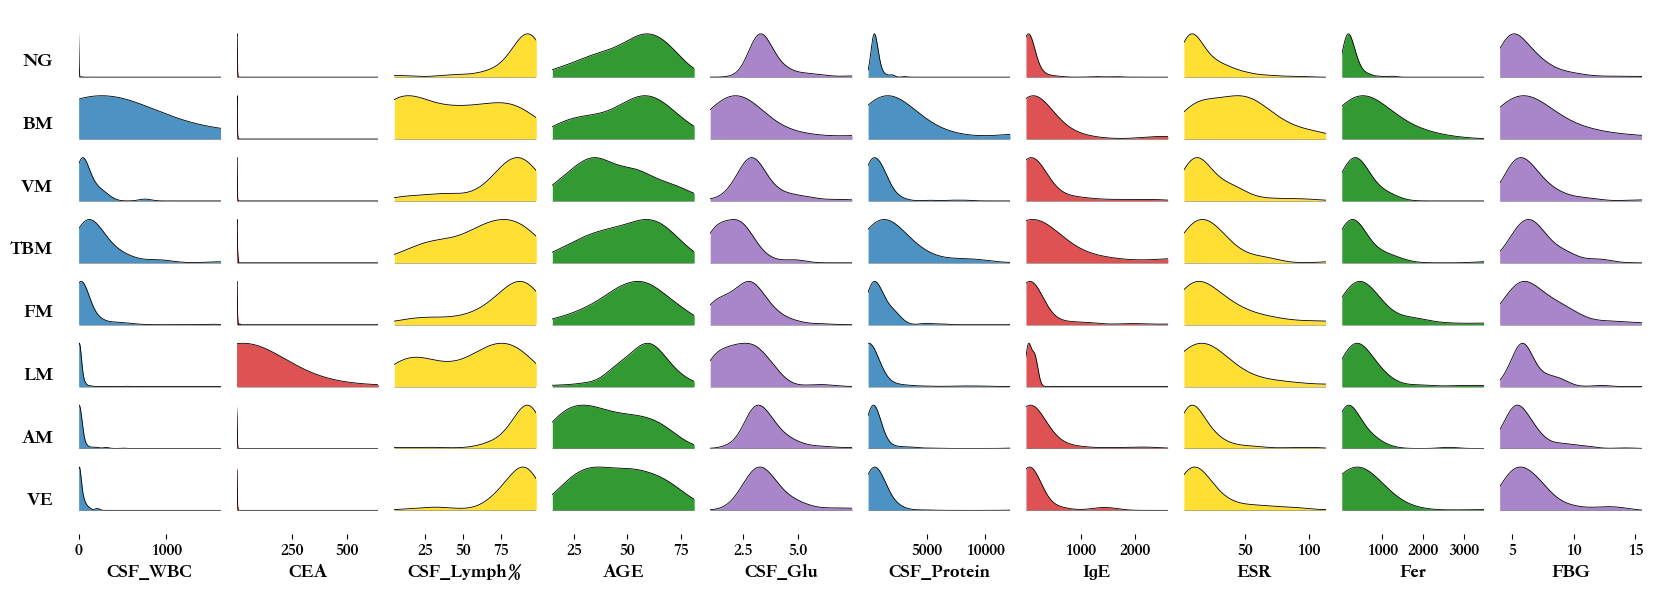

In [ ]:
# --------------------------------------------------峰峦图-------------------------------------------------------

df2 = pd.read_csv('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/all_cleaned_data.csv')
df2[df2['laboratoryName']=='结核感染T细胞阳性对照']

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

top5 = list(df_all.head(5).index)

filter_0 = filtered_df[filtered_df["分组"].isin([0])]
filter_1 = filtered_df[filtered_df["分组"].isin([1])]
filter_2 = filtered_df[filtered_df["分组"].isin([2])]
filter_3 = filtered_df[filtered_df["分组"].isin([3])]
filter_4 = filtered_df[filtered_df["分组"].isin([4])]
filter_5 = filtered_df[filtered_df["分组"].isin([5])]
filter_6 = filtered_df[filtered_df["分组"].isin([6])]
filter_8 = filtered_df[filtered_df["分组"].isin([8])]

X_1 = filter_1[list(filter_1.columns)[:-2]]
X_2 = filter_2[list(filter_2.columns)[:-2]]

def ridge_matrix_by_task_and_features(
    X, y_task, features,                      # DataFrame/Series/list
    figsize=(14, 12),
    standardize=False,                         # 是否对每个特征 z-score
    overlap=0.75,                             # 曲线重叠程度(0~1)，越大越紧凑
    bw_adjust=1.0,                            # KDE带宽调整，>1 更平滑
    colors=("tab:blue","tab:red","gold","green","tab:purple"),
    xlims="percentile",                       # "auto" | "percentile"
    prange=(1, 99),                           # 当 xlims="percentile" 时的分位点范围
    grids=256                                 # KDE 计算网格密度
):
    """
    生成 “列=特征、行=任务组、单元=该任务在该特征上的 joy 曲线” 的组合图。
    返回 fig, axes
    """
    X = X.copy()
    y = pd.Series(y_task, index=X.index).astype("category")
    tasks = list(y.cat.categories)            # 固定任务顺序（可改成 value_counts 排序）
    tasks = ['NG','BM','VM','TBM','FM','LM','AM','VE']
    print(tasks)
    # 可选：按特征做 z-score（让不同量纲可比，曲线形状更直观）
    if standardize:
        for f in features:
            s = X[f]
            X[f] = (s - s.mean()) / (s.std(ddof=0) + 1e-12)

    n_tasks = len(tasks)
    n_cols = len(features)

    fig, axs = plt.subplots(
        nrows=1, ncols=n_cols, figsize=figsize, sharey=True
    )

    if n_cols == 1:
        axs = [axs]

    # y 方向：给每个任务一个整数位置：0,1,2,... 让最上面是 tasks[0]
    y_pos = np.arange(n_tasks)[::-1]  # 倒序让第一个任务在最上边
    # 每条曲线的“相对高度”（填充的最大高度），根据 overlap 控制
    ridge_height = (1.0 - overlap) if overlap < 1.0 else 0.01
    ridge_height = max(0.05, ridge_height)    # 保底，不至于完全重叠

    for j, feat in enumerate(features):
        ax = axs[j]
        c = colors[j % len(colors)]

        # 确定该列（该特征）的 x 轴范围
        col = X[feat].dropna()
        if len(col) == 0:
            continue
        if xlims == "percentile":
            xmin, xmax = np.percentile(col, prange)
        else:
            xmin, xmax = col.min(), col.max()
        if xmin == xmax:
            xmin -= 0.5
            xmax += 0.5
        xgrid = np.linspace(xmin, xmax, grids)

        # 逐任务画“小 joy 曲线”
        for i, t in enumerate(tasks):
            vals = X.loc[y == t, feat].dropna()
            if len(vals) < 3:
                # 样本很少：用窄高斯代替，避免KDE报错
                mu = vals.mean() if len(vals) else (xmin + xmax) / 2
                sd = (xmax - xmin) / 40
                kde_y = np.exp(-0.5 * ((xgrid - mu) / sd) ** 2)
            else:
                kde = gaussian_kde(vals, bw_method='scott')
                # 带宽微调
                kde.set_bandwidth(kde.factor * bw_adjust)
                kde_y = kde(xgrid)

            # 归一化，让每条曲线高度相近（便于叠放）
            if np.max(kde_y) > 0:
                kde_y = kde_y / np.max(kde_y) * ridge_height

            base = y_pos[i]
            ax.fill_between(xgrid, base, base + kde_y, alpha=0.8, linewidth=0, color=c)
            ax.plot(xgrid, base + kde_y, color="black", linewidth=0.6)
            # 细的基线
            ax.hlines(base, xmin, xmax, colors="gray", linewidth=0.4)

        # 轴样式
        ax.set_xlim(xmin, xmax)
        # ax.set_title(feat, fontsize=12)
        ax.spines[["top","right","left","bottom"]].set_visible(False)
        ax.tick_params(axis='x', labelsize=12)
        if j > 0:
            ax.set_yticks([])   # 只在第一列显示任务名
        else:
            ax.set_yticks(y_pos)
            ax.set_yticklabels(tasks, fontsize=12)
            # ax.set_ylabel("任务组", fontsize=10)

        ax.set_xlabel("z-score" if standardize else feat, fontsize=14)

    plt.tight_layout()

    left_ax = fig.add_axes([0.02, 0.12, 0.12, 0.76])   # [left, bottom, width, height] 0~1
    left_ax.set_xlim(0, 1)
    left_ax.set_ylim(-0.5, len(tasks)-0.5)
    bias = 0.6
    for yi, name in zip(y_pos, tasks):
        left_ax.text(-0.2, yi+bias, str(name), va="center", ha="right", fontsize=14)
        bias -= 0.1

    left_ax.axis("off")  

    return fig, axs

disease = {
    "真菌性脑膜炎": "FM",
    "病毒性脑炎": "VE",
    "病毒性脑膜炎": "VM",
    "自身免疫性脑膜炎": "AM",
    "结核性脑膜炎": "TBM",
    "阴性组": "NG",
    "肿瘤性脑膜炎": "LM",
    "细菌性脑膜炎": "BM"
}
features =  list(df_all.head(10).index)
y_task = [disease[x] for x in filtered_df["组名"]]
filtered_df = filtered_df[features]

new_columns = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(filtered_df.columns)]
column_trans = [trans_dict[x] for x in new_columns]
filtered_df.columns = column_trans

fig, axs = ridge_matrix_by_task_and_features(
    filtered_df, y_task, list(filtered_df.columns),
    figsize=(16, 6),
    standardize=False,     # 如果想用原始量纲，设 False
    overlap=0.3,         # 越大越紧凑
    bw_adjust=1.2,        # 更平滑
    prange=(1, 99),       # 裁掉极端值，提高可读性
)

fig.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/ridge_matrix.png')

# fig.savefig("joyplots/ridge_matrix.png", dpi=220, bbox_inches="tight")


In [427]:
pd.Series(["_".join(x.split('_')[:-1]) for x in filtered_df.columns[:-2]], name="name").to_csv("out.csv", index=False, encoding="utf-8-sig")

In [ ]:
asks = ['阴性组vs其他/', '感染性脑膜炎v非感染组/', '细菌性脑膜炎vs其他感染性脑膜炎/', '病毒性脑膜炎vs其他感染性脑膜炎/', '结核性脑膜炎vs其他感染性脑膜炎/', '真菌性脑膜炎vs其他感染性脑膜炎/', '肿瘤性脑膜炎vs其他/', 
         '自身免疫性脑膜炎vs其他/', '病毒性脑膜炎vs病毒性脑炎/']

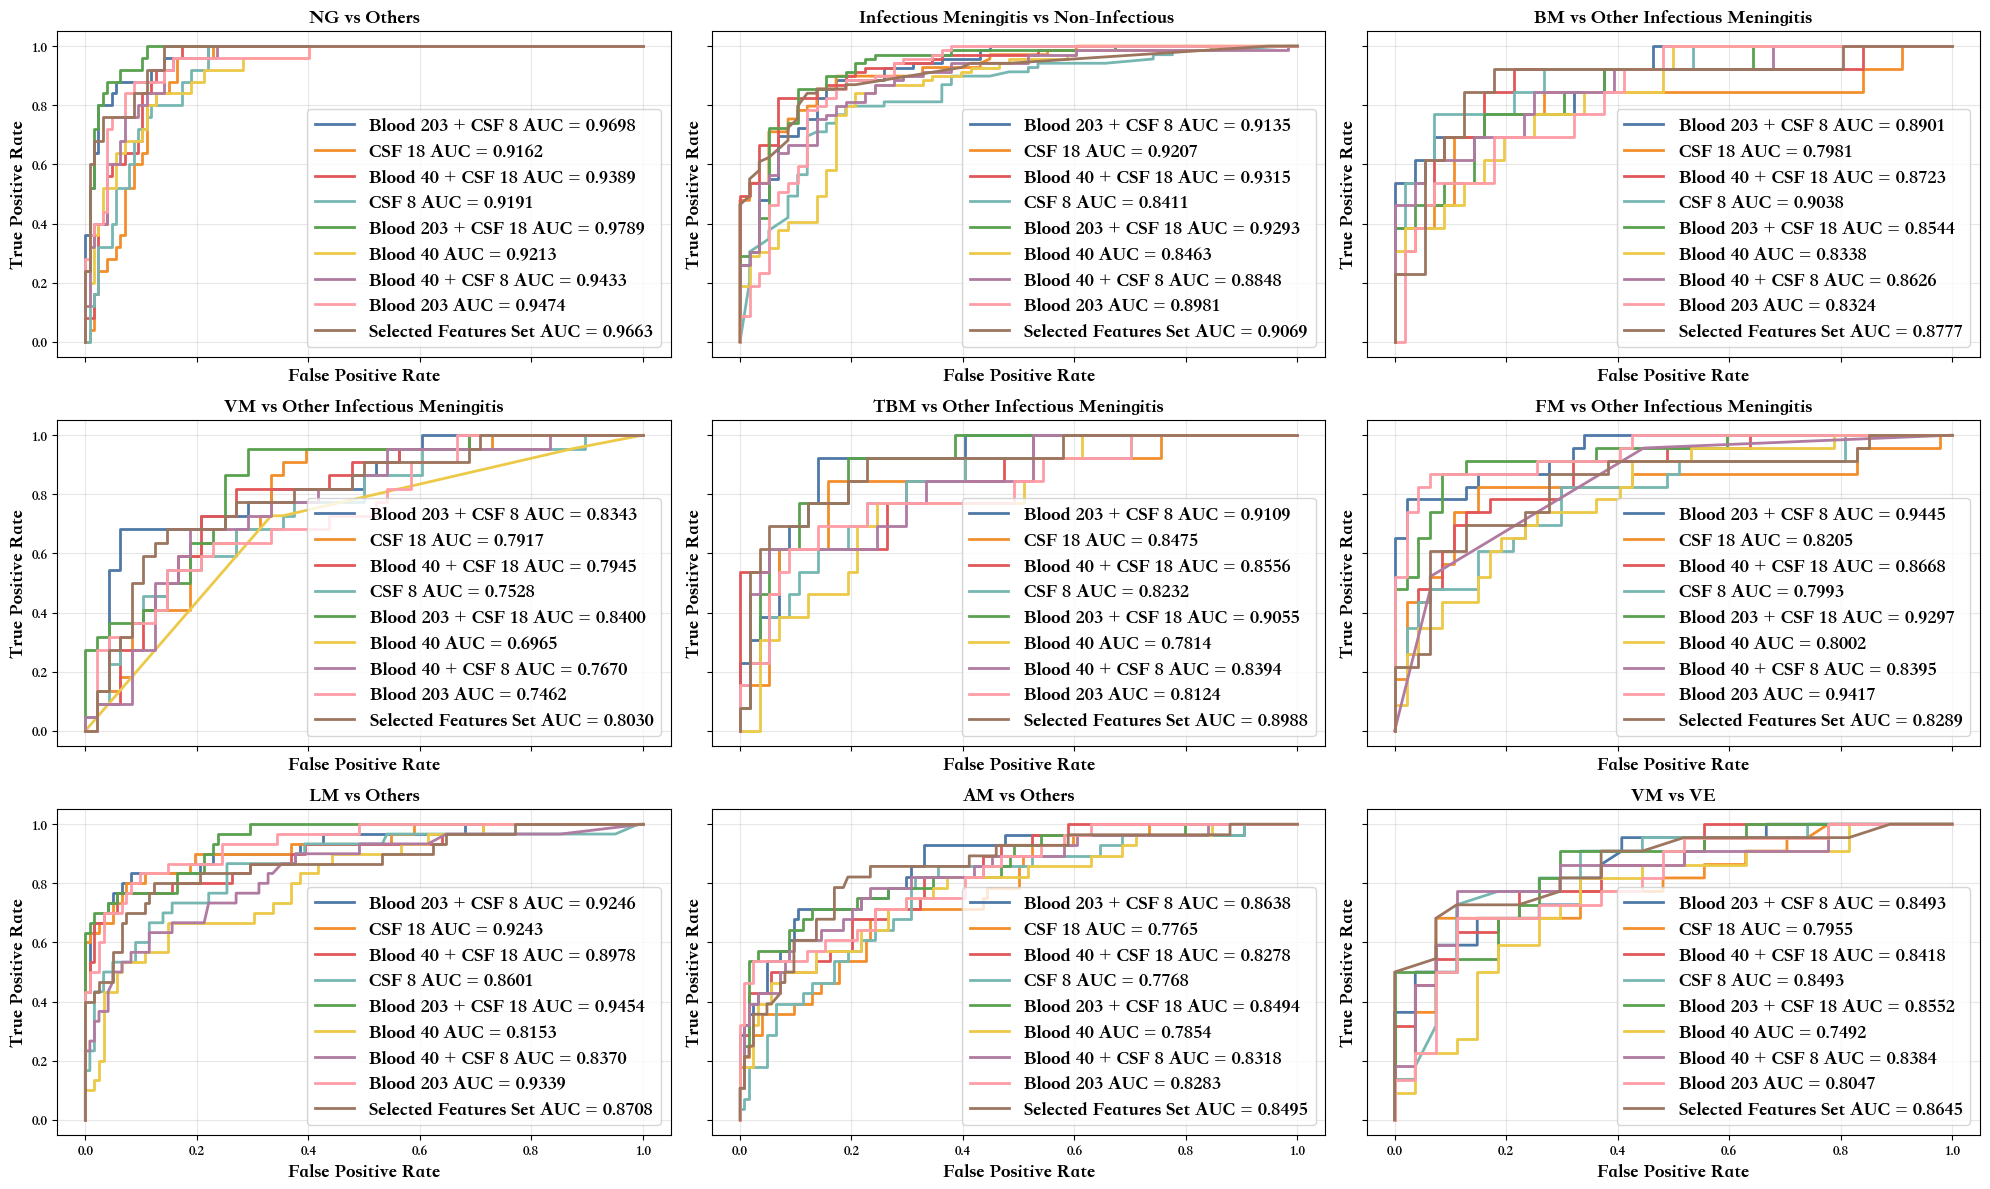

In [ ]:
# --------------------------------------------------合并生成多张auc-roc图------------------------------------------------------

roc_data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_roc/'

roc_path = os.listdir(roc_data_path)
# roc_path = [x+"/" for x in roc_path]
fig, axes = plt.subplots(3, 3, figsize=(20, 12), sharex=True, sharey=True)
axes = axes.flatten()

# 图1: 整体实验概览（左上，跨2列）
roc_path = ['阴性组vs其他', '感染性脑膜炎vs非感染性脑膜炎', '细菌性脑膜炎vs其他感染性脑膜炎', '病毒性脑膜炎vs其他感染性脑膜炎', '结核性脑膜炎vs其他感染性脑膜炎', '真菌性脑膜炎vs其他感染性脑膜炎', '肿瘤性脑膜炎vs其他',  '自身免疫性脑膜炎vs其他', '病毒性脑膜炎vs病毒性脑炎']
for i, path in enumerate(roc_path):
    # ax = fig.add_subplot(gs[0, :2])
    roc_data = os.listdir(roc_data_path+path+'/')

    colors = ["#4E79A7","#F28E2B","#E15759","#76B7B2","#59A14F","#EDC948","#B07AA1","#FF9DA7","#9C755F"]
    name_trans = {'Dataset8_roc_curve': '血液203+脑脊液8',
    'Dataset5_roc_curve': '脑脊液18项',
    'Dataset1_roc_curve': '血液40项+脑脊液18项',
    'Dataset6_roc_curve': '脑脊液8项',
    'Dataset2_roc_curve': '血液203项+脑脊液18项',
    'Dataset3_roc_curve': '血液40项',
    'Dataset7_roc_curve': '血液40项+脑脊液8项',
    'Dataset4_roc_curve': '血液203项',
    'Dataset9_roc_curve': '精选特征集'}

    # ax1.figure(figsize=(12, 10))

    for j, roc in enumerate(roc_data):
        roc_df = pd.read_csv(roc_data_path+path+'/'+roc)

        fpr = list(roc_df['fpr'])
        tpr = list(roc_df['tpr'])
        auc_value = auc(fpr, tpr)
        roc_name = roc.split('.')[0]
        axes[i].plot(fpr, tpr, color=colors[j], lw=2, 
            label=f'{feature_comb_trans[name_trans[roc_name]]} AUC = {auc_value:.4f}')
    

    # axes[i].xlim([0.0, 1.0])
    # axes[i].ylim([0.0, 1.05])

    axes[i].set_xlabel('False Positive Rate', fontsize=14)
    axes[i].set_ylabel('True Positive Rate', fontsize=14)
    axes[i].set_title(task_trans2[path], fontsize=14)
    axes[i].legend(loc="lower right", fontsize=14)
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
    # axes[i].savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/merged_ROC/{path}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG

plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/ROC.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)

plt.show()

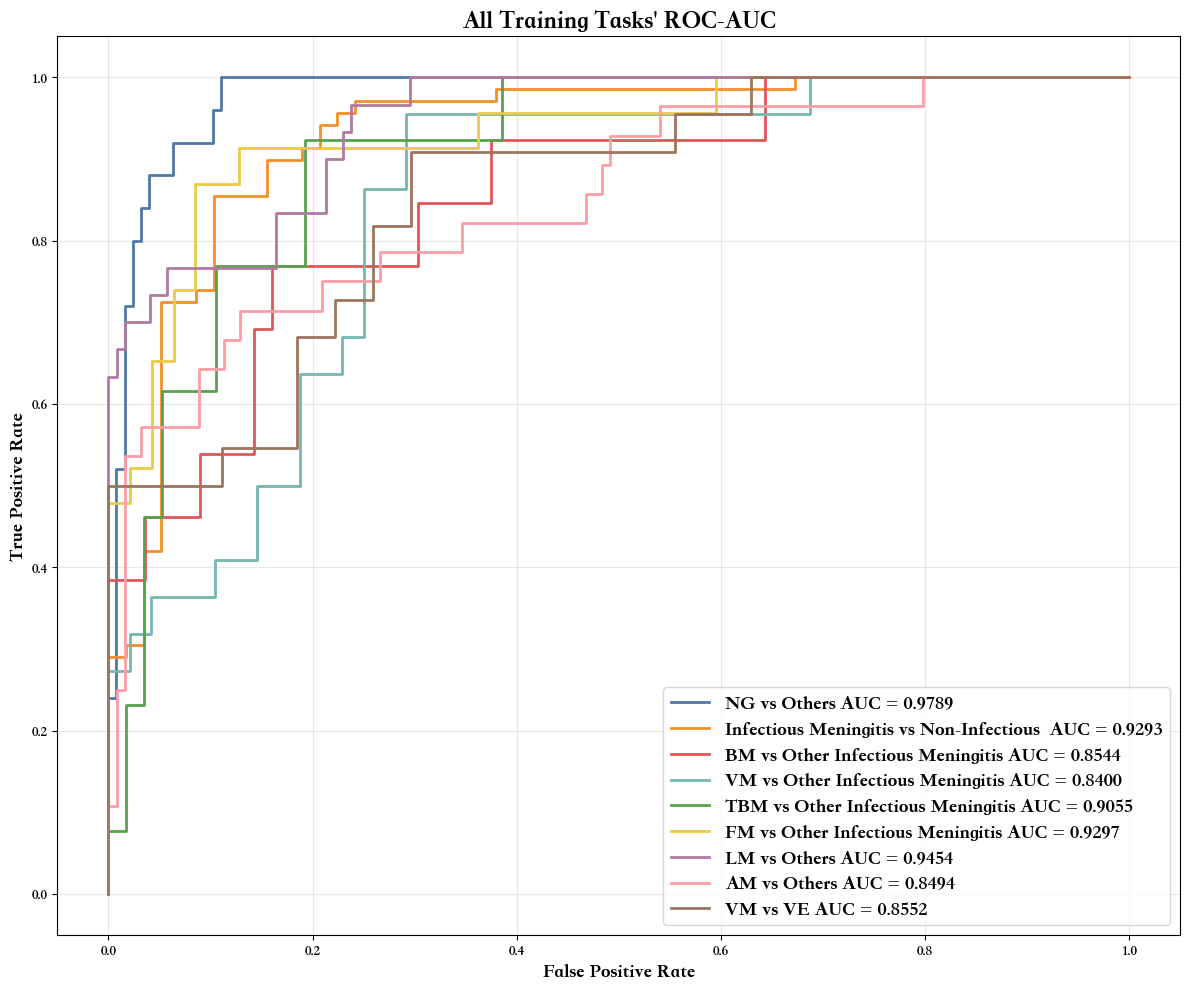

In [ ]:
# --------------------------------------------------合并生成单张auc-roc图------------------------------------------------------

roc_data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/'

roc_path = os.listdir(roc_data_path)
# roc_path = [x+"/" for x in roc_path]
# fig, axes = plt.subplots(3, 3, figsize=(20, 12), sharex=True, sharey=True)
plt.figure(figsize=(12, 10))
axes = axes.flatten()

# 图1: 整体实验概览（左上，跨2列）
roc_path = ['LR+XGBoost3/阴性组vs其他', 'LR+XGBoost2/感染性脑膜炎vs非感染性脑膜炎', 'RF/细菌性脑膜炎vs其他感染性脑膜炎', 'LR+XGBoost2/病毒性脑膜炎vs其他感染性脑膜炎', 'LR+XGBoost3/结核性脑膜炎vs其他感染性脑膜炎', 'RF/真菌性脑膜炎vs其他感染性脑膜炎', 'LR+XGBoost2/肿瘤性脑膜炎vs其他',  'LR+XGBoost3/自身免疫性脑膜炎vs其他', 'LR+XGBoost2/病毒性脑膜炎vs病毒性脑炎']
for i, path in enumerate(roc_path):
    # ax = fig.add_subplot(gs[0, :2])
    roc_data = os.listdir(roc_data_path+path+'/')

    colors = ["#4E79A7","#F28E2B","#E15759","#76B7B2","#59A14F","#EDC948","#B07AA1","#FF9DA7","#9C755F"]
    name_trans = {'Dataset8_roc_curve': '血液203+脑脊液8',
    'Dataset5_roc_curve': '脑脊液18项',
    'Dataset1_roc_curve': '血液40项+脑脊液18项',
    'Dataset6_roc_curve': '脑脊液8项',
    'Dataset2_roc_curve': '血液203项+脑脊液18项',
    'Dataset3_roc_curve': '血液40项',
    'Dataset7_roc_curve': '血液40项+脑脊液8项',
    'Dataset4_roc_curve': '血液203项',
    'Dataset9_roc_curve': '精选特征集'}

    # ax1.figure(figsize=(12, 10))
    roc = 'Dataset2_roc_curve.csv'
    roc_df = pd.read_csv(roc_data_path+path+"/"+roc)

    fpr = list(roc_df['fpr'])
    tpr = list(roc_df['tpr'])
    auc_value = auc(fpr, tpr)
    roc_name = roc.split('.')[0]
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
        label=f'{task_trans2[path.split("/")[1]]} AUC = {auc_value:.4f}')
    
    # axes[i].xlim([0.0, 1.0])
    # axes[i].ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title("All Training Tasks' ROC-AUC", fontsize=18)
    plt.legend(loc="lower right", fontsize=14)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
    # axes[i].savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/merged_ROC/{path}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG

plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/ROC_1.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)

plt.show()

Saved: /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/特征重要性.png


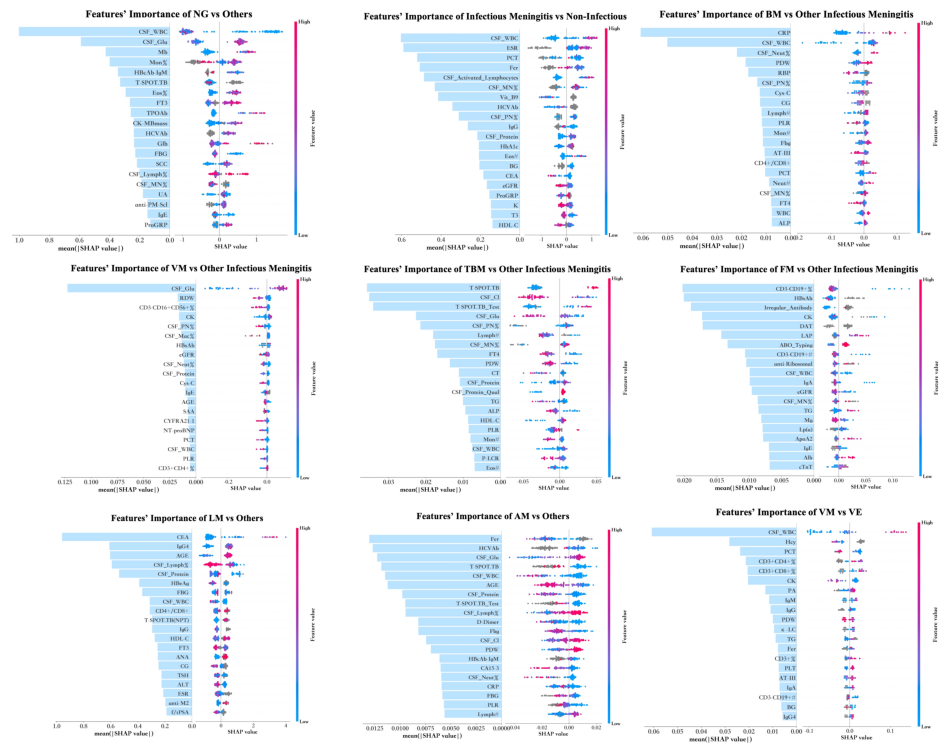

In [ ]:
# --------------------------------------------------合并多张shap图------------------------------------------------------

# === 自定义参数 ===
IMG_DIR = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap"       # 放9张图的文件夹
PATTERN = "*.png"                    # 或者 "*.jpg"
SAVE_PATH = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/特征重要性.png"  # 合并后输出路径
SHOW_TITLES = False                   # 是否在每张子图上方显示文件名
ROWS, COLS = 3, 3

def natural_key(s):
    # 自然排序：shap2.png < shap10.png
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', os.path.basename(s))]

# 收集与排序
files = sorted(glob.glob(os.path.join(IMG_DIR, PATTERN)), key=natural_key)

# 只取前9张，不足9张用 None 占位
max_n = ROWS * COLS
files = (files + [None] * max(0, max_n - len(files)))[:max_n]

# 自动设定画布大小（每张子图宽高可按需调整）
fig_w_per_col = 4.0
fig_h_per_row = 3.2
fig = plt.figure(figsize=(COLS * fig_w_per_col, ROWS * fig_h_per_row))
plt.subplots_adjust(wspace=0.01, hspace=0.01)
files = ['/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/阴性组vs其他.png', '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/感染性脑膜炎vs非感染性脑膜炎.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/细菌性脑膜炎vs其他感染性脑膜炎.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/病毒性脑膜炎vs其他感染性脑膜炎.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/结核性脑膜炎vs其他感染性脑膜炎.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/真菌性脑膜炎vs其他感染性脑膜炎.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/肿瘤性脑膜炎vs其他.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/自身免疫性脑膜炎vs其他.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/shap/病毒性脑膜炎vs病毒性脑炎.png']
for idx, fp in enumerate(files):
    r = idx // COLS
    c = idx % COLS
    ax = plt.subplot(ROWS, COLS, idx + 1)
    ax.axis("off")

    if fp is None:
        # 空白占位
        ax.set_facecolor("white")
        continue

    img = imread(fp)
    ax.imshow(img)
    if SHOW_TITLES:
        title = os.path.splitext(os.path.basename(fp))[0]
        ax.set_title(title, fontsize=10, pad=6)

# 保存高分辨率大图
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
print(f"Saved: {SAVE_PATH}")
# 如需在交互环境里预览，也可以：plt.show()


Saved: /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/混淆矩阵.png


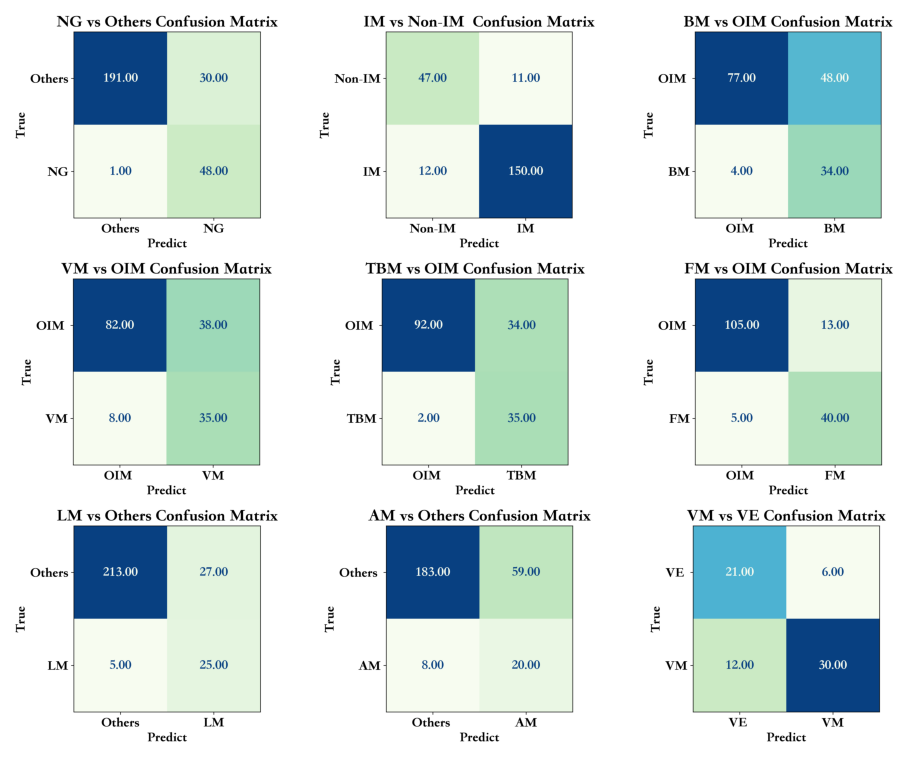

In [ ]:
# --------------------------------------------------合并多张混淆矩阵图------------------------------------------------------

# === 自定义参数 ===
IMG_DIR = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix"       # 放9张图的文件夹
PATTERN = "*.png"                    # 或者 "*.jpg"
SAVE_PATH = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/混淆矩阵.png"  # 合并后输出路径
SHOW_TITLES = False                   # 是否在每张子图上方显示文件名
ROWS, COLS = 3, 3

def natural_key(s):
    # 自然排序：shap2.png < shap10.png
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', os.path.basename(s))]

# 收集与排序
files = sorted(glob.glob(os.path.join(IMG_DIR, PATTERN)), key=natural_key)

# 只取前9张，不足9张用 None 占位
max_n = ROWS * COLS
files = (files + [None] * max(0, max_n - len(files)))[:max_n]

# 自动设定画布大小（每张子图宽高可按需调整）
fig_w_per_col = 4.0
fig_h_per_row = 3.2
fig = plt.figure(figsize=(COLS * fig_w_per_col, ROWS * fig_h_per_row))
plt.subplots_adjust(wspace=0.01, hspace=0.01)
files = ['/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/阴性组vs其他混淆矩阵.png', '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/感染性脑膜炎v非感染组混淆矩阵.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/细菌性脑膜炎vs其他感染性脑膜炎混淆矩阵.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/病毒性脑膜炎vs其他感染性脑膜炎混淆矩阵.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/结核性脑膜炎vs其他感染性脑膜炎混淆矩阵.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/真菌性脑膜炎vs其他感染性脑膜炎混淆矩阵.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/肿瘤性脑膜炎vs其他混淆矩阵.png','/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/自身免疫性脑膜炎vs其他混淆矩阵.png',
         '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/matrix/病毒性脑膜炎vs病毒性脑炎混淆矩阵.png']
for idx, fp in enumerate(files):
    r = idx // COLS
    c = idx % COLS
    ax = plt.subplot(ROWS, COLS, idx + 1)
    ax.axis("off")

    if fp is None:
        # 空白占位
        ax.set_facecolor("white")
        continue

    img = imread(fp)
    ax.imshow(img)
    if SHOW_TITLES:
        title = os.path.splitext(os.path.basename(fp))[0]
        ax.set_title(title, fontsize=10, pad=6)


# 保存高分辨率大图
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
print(f"Saved: {SAVE_PATH}")
# 如需在交互环境里预览，也可以：plt.show()


In [ ]:
# --------------------------------------------------横向拼图 radar-boxplot--------------------------------------------------


left_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/radar.png'
right_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/boxplot.png'

def read_then_resize_h(path, target_h=None):
    im = Image.open(path).convert("RGB")         # 统一到RGB避免通道不一致
    if target_h is not None and im.height != target_h:
        new_w = round(im.width * target_h / im.height)
        im = im.resize((new_w, target_h), Image.BICUBIC)
    return np.asarray(im)

L = read_then_resize_h(left_path)
R = read_then_resize_h(right_path, target_h=L.shape[0]) 
# 高度不一致时先按比例缩放 R 到与 L 高度一致（略）
merged = np.concatenate([L, R], axis=1)
plt.imsave('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/radar_box.png', merged)


In [ ]:
# --------------------------------------------------纵向拼图 radar-boxplot--------------------------------------------------

top_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/radar.png'
bottom_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/1/boxplot.png'
save_path  = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/radar_box1.png"

def read_then_resize_w(path, target_w=None):
    im = Image.open(path).convert("RGB")
    if target_w is not None and im.width != target_w:
        new_h = round(im.height * target_w / im.width)
        im = im.resize((target_w, new_h), Image.BICUBIC)
    return np.asarray(im)

T = read_then_resize_w(top_path)
B = read_then_resize_w(bottom_path, target_w=T.shape[1])  # 拉到底图与顶图同宽

merged = np.concatenate([T, B], axis=0)  # 纵向拼
Image.fromarray(merged).save(save_path)
print("Saved ->", save_path)


Saved -> /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/radar_box1.png


In [ ]:
# --------------------------------------------------横向拼图 radar_box1_roc-混淆矩阵--------------------------------------------------

left_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/radar_box1.png'
right_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/ROC_混淆矩阵.png'
def read_then_resize_h(path, target_h=None):
    im = Image.open(path).convert("RGB")         # 统一到RGB避免通道不一致
    if target_h is not None and im.height != target_h:
        new_w = round(im.width * target_h / im.height)
        im = im.resize((new_w, target_h), Image.BICUBIC)
    return np.asarray(im)

L = read_then_resize_h(left_path)
R = read_then_resize_h(right_path, target_h=L.shape[0]) 
# 高度不一致时先按比例缩放 R 到与 L 高度一致（略）
merged = np.concatenate([L, R], axis=1)
plt.imsave('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/radar_box_ROC_混淆矩阵.png', merged)


In [ ]:
# --------------------------------------------------纵向拼图 roc-混淆矩阵--------------------------------------------------

top_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/3/ROC_1.png'
bottom_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/3/混淆矩阵.png'
save_path  = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/ROC_混淆矩阵.png"

def read_then_resize_w(path, target_w=None):
    im = Image.open(path).convert("RGB")
    if target_w is not None and im.width != target_w:
        new_h = round(im.height * target_w / im.width)
        im = im.resize((target_w, new_h), Image.BICUBIC)
    return np.asarray(im)

T = read_then_resize_w(top_path)
B = read_then_resize_w(bottom_path, target_w=T.shape[1])  # 拉到底图与顶图同宽

merged = np.concatenate([T, B], axis=0)  # 纵向拼
Image.fromarray(merged).save(save_path)
print("Saved ->", save_path)


Saved -> /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/ROC_混淆矩阵.png


In [ ]:
# --------------------------------------------------纵向拼图 特征组合-auc热力图--------------------------------------------------

top_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/4/distribution_features_histogram.png'
bottom_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/4/AUC热力图.png'
save_path  = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/特征组合-auc热力图.png"

def read_then_resize_w(path, target_w=None):
    im = Image.open(path).convert("RGB")
    if target_w is not None and im.width != target_w:
        new_h = round(im.height * target_w / im.width)
        im = im.resize((target_w, new_h), Image.BICUBIC)
    return np.asarray(im)

T = read_then_resize_w(top_path)
B = read_then_resize_w(bottom_path, target_w=T.shape[1])  # 拉到底图与顶图同宽

merged = np.concatenate([T, B], axis=0)  # 纵向拼
Image.fromarray(merged).save(save_path)
print("Saved ->", save_path)


Saved -> /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/特征组合-auc热力图.png


In [ ]:
# --------------------------------------------------拼三张图 heetmap_netplot_ridge--------------------------------------------------

# ===== 必填：三张图路径 =====
top_left_path   = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/heatmap.png"
top_right_path  = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/netplot.png"
bottom_path     = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/2/ridge_matrix.png"
save_path       = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/heetmap_netplot_ridge.png"

# ===== 可调参数 =====
gap_h = 20   # 横向间距（上排左右之间）
gap_v = 30   # 纵向间距（上排与下图之间）
bg    = (255, 255, 255)  # 画布背景色
match_top_height = True          # 是否让上排两图按高度等比对齐（常用）
resize_bottom_to_row_width = True  # 是否将下图等比缩放到与上排总宽一致

# 读图
TL = Image.open(top_left_path).convert("RGB")
TR = Image.open(top_right_path).convert("RGB")
B  = Image.open(bottom_path).convert("RGB")

# --- 1) 上排：两图等高（或仅补白） ---
if match_top_height:
    target_h = max(TL.height, TR.height)
    def resize_to_h(img, h):
        if img.height == h: return img
        new_w = round(img.width * h / img.height)
        return img.resize((new_w, h), Image.BICUBIC)
    TL = resize_to_h(TL, target_h)
    TR = resize_to_h(TR, target_h)
else:
    # 不缩放，仅补白到相同高度并顶对齐
    target_h = max(TL.height, TR.height)
    def pad_to_h(img, h):
        canvas = Image.new("RGB", (img.width, h), bg)
        canvas.paste(img, (0, 0))
        return canvas
    TL, TR = pad_to_h(TL, target_h), pad_to_h(TR, target_h)

row_w = TL.width + gap_h + TR.width
row_h = TL.height  # 与 TR.height 一致

# --- 2) 下图：等比缩放到与上排总宽一致（或补白居中） ---
if resize_bottom_to_row_width:
    if B.width != row_w:
        new_h = round(B.height * row_w / B.width)
        B = B.resize((row_w, new_h), Image.BICUBIC)
    bottom_w, bottom_h = B.width, B.height
else:
    # 不缩放，仅水平居中补白到 row_w
    bottom_h = B.height
    canvas_B = Image.new("RGB", (row_w, bottom_h), bg)
    x = (row_w - B.width) // 2
    canvas_B.paste(B, (x, 0))
    B = canvas_B
    bottom_w, bottom_h = B.width, B.height

# --- 3) 组装画布 ---
final_w = row_w
final_h = row_h + gap_v + bottom_h

canvas = Image.new("RGB", (final_w, final_h), bg)

# 上排左图（顶左）
canvas.paste(TL, (0, 0))
# 上排右图（顶右，留间距）
canvas.paste(TR, (TL.width + gap_h, 0))
# 下图（居中：此时 B 宽度等于 row_w；若不缩放逻辑已补白到 row_w）
canvas.paste(B, (0, row_h + gap_v))

# 保存
canvas.save(save_path, quality=95)
print("Saved ->", save_path)


Saved -> /Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/heetmap_netplot_ridge.png


In [10]:

# --------------------------------------------------使用PCA和UMAP生成样本分布图--------------------------------------------------

def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  
    
    return filtered_df
    

[0 1 2 3 4 5 6 8]


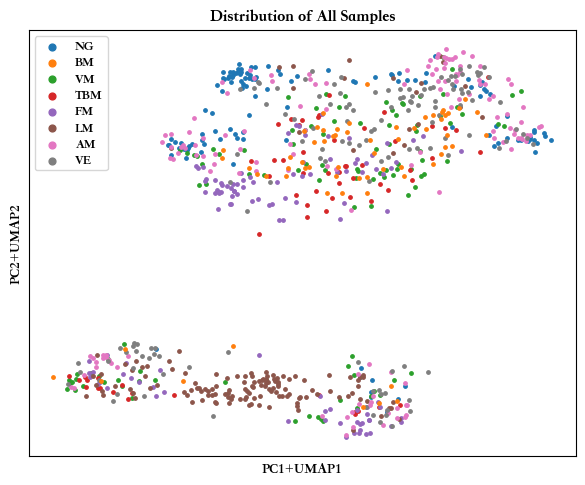

In [11]:

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

filtered_df = label_encoding(filtered_df, data_path)

filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

task_trans = {'阴性组vs其他': 'NG vs Others',
 '感染性脑膜炎vs非感染性脑膜炎': 'Infectious Meningitis vs Non-Infectious ',
 '细菌性脑膜炎vs其他感染性脑膜炎': 'BM vs Other Infectious Meningitis',
 '病毒性脑膜炎vs其他感染性脑膜炎': 'VM vs Other Infectious Meningitis',
 '结核性脑膜炎vs其他感染性脑膜炎': 'TBM vs Other Infectious Meningitis',
 '真菌性脑膜炎vs其他感染性脑膜炎': 'FM vs Other Infectious Meningitis',
 '肿瘤性脑膜炎vs其他': 'LM vs Others',
 '自身免疫性脑膜炎vs其他': 'AM vs Others',
 '病毒性脑膜炎vs病毒性脑炎': 'VM vs VE'}

screen_data = {
    '阴性组vs其他':[[8], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[0,8], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[0,8,5,6], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[0,8,5,6], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[0,8,5,6], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[0,8,5,6], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[8], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[8], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[0,1,3,4,5,6], [2], [8]]
    }

X = filtered_df.iloc[:, :-2].copy()

# 8类
y8 = filtered_df['分组'].astype(int).values  

y_list = {}
for key, item in screen_data.items():
    filtered_df1 = filtered_df.copy()
    y = np.select(
        [filtered_df1['分组'].isin(item[1]), filtered_df1['分组'].isin(item[2]), filtered_df1['分组'].isin(item[0])],
        [1, 0, 2],
        default=np.nan 
    )
    
    y_list[key] = y

name_map_bin = {
    '全局': {0: "阴性", 1: "细菌性脑膜炎", 2: "病毒性脑膜炎", 3: "结核性脑膜炎", 4: "真菌性脑膜炎", 5: "肿瘤性脑膜炎", 6: "自身免疫性脑膜炎", 8: "病毒性脑膜炎"},
    '阴性组vs其他':{1: "阴性", 0: "非阴性"},
    '感染性脑膜炎vs非感染性脑膜炎': {1: "感染性脑膜炎", 0: "非感染性脑膜炎"},
    '细菌性脑膜炎vs其他感染性脑膜炎': {1: "细菌性脑膜炎", 0: "其他感染性脑膜炎"},
    '病毒性脑膜炎vs其他感染性脑膜炎': {1: "病毒性脑膜炎", 0: "其他感染性脑膜炎"},
    '结核性脑膜炎vs其他感染性脑膜炎': {1: "结核性脑膜炎", 0: "其他感染性脑膜炎"},
    '真菌性脑膜炎vs其他感染性脑膜炎': {1: "真菌性脑膜炎", 0: "其他感染性脑膜炎"},
    '肿瘤性脑膜炎vs其他': {1: "肿瘤性脑膜炎", 0: "非肿瘤性脑膜炎"},
    '自身免疫性脑膜炎vs其他': {1: "自身免疫性脑膜炎", 0: "非自身免疫性脑膜炎"},
    '病毒性脑膜炎vs病毒性脑炎': {1: "病毒性脑膜炎", 0: "病毒性脑炎"},
    }

name_map_bin = {
    '全局': {0: "NG", 1: "BM", 2: "VM", 3: "TBM", 4: "FM", 5: "LM", 6: "AM", 8: "VE"},
    '阴性组vs其他':{1: "NG", 0: "Others"},
    '感染性脑膜炎vs非感染性脑膜炎': {1: "Infectious Meningitis", 0: "Non-Infectious"},
    '细菌性脑膜炎vs其他感染性脑膜炎': {1: "BM", 0: "Other Infectious Meningitis"},
    '病毒性脑膜炎vs其他感染性脑膜炎': {1: "VM", 0: "Other Infectious Meningitis"},
    '结核性脑膜炎vs其他感染性脑膜炎': {1: "TBM", 0: "Other Infectious Meningitis"},
    '真菌性脑膜炎vs其他感染性脑膜炎': {1: "FM", 0: "Other Infectious Meningitis"},
    '肿瘤性脑膜炎vs其他': {1: "LM", 0: "Others"},
    '自身免疫性脑膜炎vs其他': {1: "AM", 0: "Others"},
    '病毒性脑膜炎vs病毒性脑炎': {1: "VM", 0: "VE"},
    }

pipe_pca = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler(with_mean=True)),
    ("pca", PCA(n_components=50, random_state=42))
])

X50 = pipe_pca.fit_transform(X)

umap_model = UMAP(
    n_neighbors=40,       
    min_dist=0.1,
    metric='euclidean',
    init='spectral',
    random_state=42
)
emb = umap_model.fit_transform(X50)  

def plot_umap(emb, labels, title, label_names=None, cmap_name='tab10'):
    plt.figure(figsize=(6,5))
    cmap = plt.get_cmap(cmap_name)
    classes = np.unique(labels)
    print(classes)
    for i, cls in enumerate(classes):
        mask = (labels == cls)
        # if cls == 2:
        #     continue
        # else:
        z = 10 if cls == 1 else 1
        plt.scatter(emb[mask, 0], emb[mask, 1], s=6, color=cmap(i % 10), zorder=z,
                    label=(label_names[cls] if (label_names and cls in label_names) else str(cls)))

    plt.title(title)
    plt.legend(loc='best', fontsize=9, markerscale=2)
    plt.tight_layout()
    # plt.axis('off')
    plt.xticks([])
    plt.yticks([])
    plt.xlabel("PC1+UMAP1")
    plt.ylabel("PC2+UMAP2")
    plt.savefig('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/need/样本总体分布.png', dpi=300, bbox_inches='tight',facecolor='white', edgecolor='none',pad_inches=0.2)
    plt.show()

# 按“分组”多类配色
plot_umap(emb, y8, title="Distribution of All Samples", label_names=name_map_bin['全局'])

# for k1, i1 in screen_data.items():
#     print(k1)
#     plot_umap(emb, y_list[k1], title=f"{task_trans[k1]}", label_names=name_map_bin[k1])



In [12]:
# --------------------------------------------------扩充数据--------------------------------------------------

def sample_and_jitter(
    df: pd.DataFrame,
    group_col: str,
    n_per_group=3,
    emb_cols=("emb_X", "emb_y"),
    jitter_mode="relative",
    rel_sigma=0.05,
    abs_sigma=0.02,
    replace_if_small=True,
    random_state=None,
    add_flag=True,          # 给新增行打标
    verbose=True            # 打印执行摘要
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    # 基本检查
    missing_cols = [c for c in emb_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"缺少列：{missing_cols}")
    if group_col not in df.columns:
        raise KeyError(f"找不到分组列：{group_col}")

    # 解析每组抽取数量
    if isinstance(n_per_group, int):
        n_map = {g: n_per_group for g in df[group_col].unique()}
    elif isinstance(n_per_group, dict):
        n_map = n_per_group
    else:
        raise ValueError("n_per_group 需为 int 或 dict")

    base = df.copy()
    if add_flag and "is_aug" not in base.columns:
        base["is_aug"] = 0

    parts = [base]
    grouped = df.groupby(group_col, dropna=False)

    # relative 模式需要组内 std
    if jitter_mode == "relative":
        gstd = grouped[list(emb_cols)].std(ddof=0)
        global_std = df[list(emb_cols)].std(ddof=0).replace(0, np.nan)
        gstd = gstd.fillna(global_std).fillna(1.0)

    add_counts = {}  # 记录每组新增条数

    for g, gdf in grouped:
        k = int(n_map.get(g, 0))
        if k <= 0:
            add_counts[g] = 0
            continue

        can_replace = replace_if_small or (len(gdf) >= k)
        if not can_replace and len(gdf) < k:
            # 不放回且样本不足，直接跳过
            add_counts[g] = 0
            continue

        picked = gdf.sample(n=k, replace=can_replace, random_state=random_state).copy()

        # 抖动
        if jitter_mode == "relative":
            scales = (gstd.loc[g] * rel_sigma).to_dict()
            for c in emb_cols:
                picked[c] = picked[c].astype(float) + rng.normal(0.0, scales[c], size=len(picked))
        elif jitter_mode == "absolute":
            for c in emb_cols:
                picked[c] = picked[c].astype(float) + rng.normal(0.0, abs_sigma, size=len(picked))
        else:
            raise ValueError("jitter_mode 仅支持 'relative' 或 'absolute'")

        if add_flag:
            picked["is_aug"] = 1

        parts.append(picked)
        add_counts[g] = k

    out = pd.concat(parts, axis=0, ignore_index=True)

    if verbose:
        total_added = sum(add_counts.values())
        print(f"[OK] 原始 {len(df)} 行，新增 {total_added} 行，现有 {len(out)} 行。")
        # 显示前几组的新增情况
        preview = list(add_counts.items())[:10]
        print("每组新增（前10组预览）：", preview)
        if add_flag:
            print("out['is_aug'].value_counts():")
            print(out["is_aug"].value_counts(dropna=False))

    return out


In [ ]:
df_aug = sample_and_jitter(
    filtered_df,
    group_col="分组",
    n_per_group={0:124, 1:128, 2:107, 3:124, 4:111, 5:0, 6:0, 8:0},
    emb_cols=("emb_x","emb_y"),
    jitter_mode="absolute",
    abs_sigma=0.6,
    random_state=7
)

In [ ]:
emb_1 = []

for i, row in df_aug.iterrows():
    emb_1.append(np.array([row['emb_x'],row['emb_y']], dtype=float))
emb_1 = np.array(emb_1)
y_1 = df_aug['分组'].astype(int).values  
